- TODO: continue video and add experiments
- TODO: how does kaiming init gain help if its only for first step
- TODO: review TODOs
- TODO: review all code
- TODO: prediction vs conclusion

- TODO: batch norm
- TODO: output_layer_weight_scale
- TODO: bug saturation is being calcualted with no nonlinearity
- TODO: gradient std uses learning rate?
- TODO: fix printing of mean and std
- TODO: add final run, test running batch norm before and after activations, test adding or not adding to output layer
- TODO: ask gpt 4o to analyze the results of training runs and summarize the patterns that were found to draw conclusions
call plot_model_graphs run_experiment
TODO: learning rate is not always increased

# Optimizing Neural Networks: Initializations, Activations, and Gradient Flow - Part 2

This notebook is a reconstruction of Andrej Karpathy's [Building makemore Part 3: Activations & Gradients, BatchNorm](https://www.youtube.com/watch?v=P6sfmUTpUmc). It covers:
- Initializing Neural Networks effectively for better training.
- Analyzing gradient flows to identify learning bottlenecks.
- Using [Batch Normalization](https://en.wikipedia.org/wiki/Batch_normalization) to stabilize gradients during training.

The notebook was broken into two parts because the lesson was a bit too long.
The first part is here: TODO and it introduced the topics above. In this one we'll focus on starting to migrate the code to pytorch, and then perform multiple experiments with initialization and batch norm to truly understand how they affect data and gradient flow through the network to gain a more intutivie understanding.

*The purpose of this notebook is for my own self-learning, and shouldn't add much to the original lesson beyond extra verbosity. Parts of the notebook, namely the code snippets, may have been copied from the source lesson verbatim.*

## Setup


In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

import torch
import random

# Check if CUDA is available and set the device
DEVICE = torch.device("cpu")#'cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
BLOCK_SIZE = 3

words = open("names.txt", "r").read().splitlines()
len(words), words[:8]

# Create list with all unique characters found in the raw data (sorted alphabetically)
chars = sorted(list(set(''.join(words))))

# Create lookup table for converting each possible character to a unique integer
stoi_map = {s:i+1 for i,s in enumerate(chars)}
EOS_CHAR = "." # The character used to represent the end of a word
EOS_CHAR_INDEX = 0
stoi_map[EOS_CHAR] = EOS_CHAR_INDEX # Assign index zero to EOS char

# Create reverse lookup table
itos_map = {i:s for s,i in stoi_map.items()}
itos_map

# Count the size of the vocabulary
# (how many different characters exist in the dataset)
vocabulary_size = len(stoi_map)

def build_dataset(words, block_size=BLOCK_SIZE, verbose=False):
  X, Y = [], [] # Initialize the dataset
  for word in words:
    if verbose: print(word)
    context = [0] * block_size # Initialize the context with EOS characters
    for char in word + EOS_CHAR: # For each character in the current word (plus the EOS stop character)
      X.append(context) # Add the context accumulated so far as the input
      char_i = stoi_map[char] # Convert the current character to an integer
      Y.append(char_i) # Add the current character as the output (previous context must predict current character)
      if verbose: print(f"{''.join([itos_map[i] for i in context])} => {char}")
      context = context[1:] + [char_i] # Update the context by popping out the oldest character and pushing in the current one (FIFO buffer)

  # Convert the dataset to tensors and return them
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

def build_split_dataset(words, block_size=BLOCK_SIZE):
  # Shuffle the words so that the data splits are random
  words = words.copy() # Copy so we don't modify the original reference when shuffling
  random.shuffle(words)

  # Split the dataset
  n1 = int(0.8 * len(words)) # First data split point
  n2 = int(0.9 * len(words)) # Second data split point
  training_set = build_dataset(words[:n1], block_size=block_size) # Create training set from range [0%-80%]
  validation_set = build_dataset(words[n1:n2], block_size=block_size) # Create validation set from range [80%-90%]
  test_set = build_dataset(words[n2:], block_size=block_size) # Create test set from range [90%-100%]

  # Return the splits
  return training_set, validation_set, test_set

# Create the dataset and split it into training, validation and test sets
training_set, validation_set, test_set = build_split_dataset(words)

# Output the number of examples in each dataset split
n_training_set = len(training_set[0])
n_validation_set = len(validation_set[0])
n_test_set = len(test_set[0])
n_total = n_training_set + n_validation_set + n_test_set
{
    "n_total" : n_total,
    "n_training" : n_training_set,
    "n_training_percentage" : round(n_training_set / n_total * 100),
    "n_validation" : n_validation_set,
    "n_validation_percentage" : round(n_validation_set / n_total * 100),
    "n_test" : n_test_set,
    "n_test_percentage" : round(n_test_set / n_total * 100)
}

--2024-09-19 11:05:29--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.005s  

2024-09-19 11:05:29 (46.1 MB/s) - ‘names.txt’ saved [228145/228145]



{'n_total': 228146,
 'n_training': 182517,
 'n_training_percentage': 80,
 'n_validation': 22706,
 'n_validation_percentage': 10,
 'n_test': 22923,
 'n_test_percentage': 10}

## PyTorchify 🐍🔥

We need to add the code from Part 1 to continue the lesson, so let's use the opportunity to re-create it using PyTorch instead. We're going to be implementing primitives PyTorch already provides, like `Linear` and `BatchNorm1d`, but it's important to do so as a stepping stone to understand what happens inside these objects. Ultimately, we'll end up using PyTorch directly and not reinvent the wheel, but one thing at a time.

Let's start with creating a custom layer that mimics the functionality of [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html):

In [ ]:
# This is a linear layer: it performs matmul
# between input and weights, then adds a bias
class Linear:

  def __init__(self, fan_in, fan_out, bias=True, kaiming_init=True, generator=None):
    # Create layer weights with shape (fan_in, fan_out),
    # initialized using simplified kaiming init (divide by square root of fan-in)
    kaiming_scale = fan_in**0.5 if kaiming_init else 1.0
    self.weight = torch.randn((fan_in, fan_out), device=DEVICE, generator=generator) / kaiming_scale

    # Create layer biases with shape (fan_out)
    self.bias = torch.zeros(fan_out, device=DEVICE) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight # matmul between input and weights
    if self.bias is not None: self.out += self.bias # Add bias
    return self.out # Return pre-activation

  def parameters(self):
    # Return a list with all the parameters in the layer
    return [self.weight] + ([] if self.bias is None else [self.bias])

# Test the layer
Linear(1, 2)(torch.randn((2, 1), device=DEVICE))

tensor([[-0.4043, -0.6810],
        [-0.2293, -0.3863]])

Next, let's create a custom batch normalization layer that mimics the functionality of [torch.nn.BatchNorm1d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html):

In [ ]:
class BatchNorm1d:

  def __init__(
      self,
      dim,
      eps=1e-5,
      momentum=0.1
    ):
    # Small value to add during normalization
    # in order to avoid division by zero
    self.eps = eps

    # The momentum at which the current batch's statistics should
    # affect the running average statistics being kept by this
    # layer to be used later during inference
    self.momentum = momentum

    # Flag indicating if the model is being used for training or inference
    # (this layer will behave differently in each case, namely in the way it
    # retrieves the statistics to be used to normalize the inputs that go through it)
    self.training = True

    # The gain used to scale to the normalized activations (learned parameter)
    self.gamma = torch.ones(dim, device=DEVICE)

    # The bias to shift the normalized activations (learned parameter)
    self.beta = torch.zeros(dim, device=DEVICE)

    # Buffers userd to keep a running averages
    # of the batch statistics (to be used during inference)
    self.running_mean = torch.zeros(dim, device=DEVICE)
    self.running_variance = torch.ones(dim, device=DEVICE)

  def __call__(self, x):
    # In case the model is training calculate
    # the batch's mean and variance
    if self.training:
      x_mean = x.mean(0, keepdim=True)
      x_variance = x.var(0, keepdim=True)
    # Otherwise use the running statistics
    # that were calculated during training
    else:
      x_mean = self.running_mean
      x_variance = self.running_variance

    # Normalize the input by subtracting the
    # mean and dividing by the variance
    x_normalized = (x - x_mean) / torch.sqrt(x_variance + self.eps)

    # Scale and shift the normalized input and set it as the output
    self.out = self.gamma * x_normalized + self.beta

    # In case the model is training update the running
    # average statistics with the current batch statistics
    if self.training:
      # Don't track gradients during the following operations
      with torch.no_grad():
        # Add a bit of the current batch's mean to the running average of the mean
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * x_mean

        # Add a bit of the current batch's variance to the running average of the mean
        self.running_variance = (1 - self.momentum) * self.running_variance + self.momentum * x_variance

    # Return the normalized activations
    return self.out

  def parameters(self):
    # Return the layer's parameters (batch normalization needs to
    # learn how to scale and shift the normalized activations)
    return [self.gamma, self.beta]

# TODO: what does dim do?
# Test the layer
BatchNorm1d(1)(torch.randn((2, 1), device=DEVICE))

tensor([[ 0.7071],
        [-0.7071]])

Finally, let's implement a $tanh$ activation function that mimics [torch.nn.Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html):

In [ ]:
# This is a Tanh activation layer
# (e.g., to add after a linear layer)
class Tanh:

  def __call__(self, x):
    # Apply tanh to input and return result
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    # This layer has no parameters
    return []

# Test the layer
Tanh()(torch.tensor([[-0.1, 0.1], [-3, 3], [-100, 100]], device=DEVICE))

tensor([[-0.0997,  0.0997],
        [-0.9951,  0.9951],
        [-1.0000,  1.0000]])

Now that we've created all the necessary layers, let's recreate the `build_model()` method using these custom constructs. We'll also include some extra components for experiments later in the notebook:

In [ ]:
def build_model(
    vocabulary_size,
    block_size=BLOCK_SIZE,          # Number of previous characters used to predict the next character
    embedding_size=10,              # Size of the dense vector used to represent each character
    n_hidden=100,                   # Number of neurons in the hidden layer
    non_linearity=Tanh,
    batch_norm=False,
    output_layer_weight_scale=0.1,
    kaiming_init_gain=5/3,
    seed=SEED                       # The RNG seed to use when initializing parameters (for reproducibility)
):
  if batch_norm is True: batch_norm = "preactivation"

  # Initialize the generator with the provided seed
  generator = torch.Generator(DEVICE).manual_seed(seed)

  # TODO: why no generator in linear layers?
  C = torch.randn((vocabulary_size, embedding_size), generator=generator, device=DEVICE)

  kaiming_init = True if kaiming_init_gain is not None else False

  layers = [
    # Linear -> BatchNorm1d -> Tanh
    Linear(embedding_size * block_size, n_hidden, kaiming_init=kaiming_init, generator=generator),  #TODO: mirror api for kaiming init
    BatchNorm1d(n_hidden) if batch_norm == "preactivation" else None,
    non_linearity() if non_linearity else None,
    BatchNorm1d(n_hidden) if batch_norm == "activation" else None,

    # Linear -> BatchNorm1d -> Tanh
    Linear(n_hidden, n_hidden, kaiming_init=kaiming_init, generator=generator),
    BatchNorm1d(n_hidden) if batch_norm == "preactivation" else None,
    non_linearity() if non_linearity else None,
    BatchNorm1d(n_hidden) if batch_norm == "activation" else None,

    # Linear -> BatchNorm1d -> Tanh
    Linear(n_hidden, n_hidden, kaiming_init=kaiming_init, generator=generator),
    BatchNorm1d(n_hidden) if batch_norm == "preactivation" else None,
    non_linearity() if non_linearity else None,
    BatchNorm1d(n_hidden) if batch_norm == "activation" else None,

    # Linear -> BatchNorm1d -> Tanh
    Linear(n_hidden, n_hidden, kaiming_init=kaiming_init, generator=generator),
    BatchNorm1d(n_hidden) if batch_norm == "preactivation" else None,
    non_linearity() if non_linearity else None,
    BatchNorm1d(n_hidden) if batch_norm == "activation" else None,

    # Linear -> BatchNorm1d -> Tanh
    Linear(n_hidden, n_hidden, kaiming_init=kaiming_init, generator=generator),
    BatchNorm1d(n_hidden) if batch_norm == "preactivation" else None,
    non_linearity() if non_linearity else None,
    BatchNorm1d(n_hidden) if batch_norm == "activation" else None,

    # Linear -> BatchNorm1d
    Linear(n_hidden, vocabulary_size, kaiming_init=kaiming_init, generator=generator),
    BatchNorm1d(vocabulary_size) if batch_norm == "preactivation" else None
  ]
  layers = [layer for layer in layers if layer]

  # Don't track gradients for code within this block
  with torch.no_grad():
    # Make last layer less confident
    if batch_norm: layers[-1].gamma *= output_layer_weight_scale # TODO: what is going on here
    else: layers[-1].weight *= output_layer_weight_scale

    # Use tanh gain in all layers except the last one
    if kaiming_init:
      for layer in layers[:-1]:
        if isinstance(layer, Linear): layer.weight *= kaiming_init_gain

  # Enable gradient tracking for all model parameters
  parameters = [C] + [p for layer in layers for p in layer.parameters()]
  for p in parameters: p.requires_grad = True

  return layers, parameters

model = build_model(vocabulary_size)
layers, parameters = model
len(layers), sum(p.nelement() for p in parameters)

(11, 46497)

Now, let's recreate the `train()` function:

In [ ]:
import torch.nn.functional as F

# The default learning rate
LEARNING_RATE = 0.1

def train(
    dataset,           # The dataset to train on (a tuple with a list of inputs and a list of respective outputs)
    model,             # The model parameters
    n_steps,           # Train for N steps
    learning_rate=LEARNING_RATE, # The scale at which gradients should be applied to the parameters at each step
    batch_size=32,     # The size of the mini-batch to randomly sample in each step
    log_steps=10_000,  # How frequently should training progress be logged
    seed=SEED          # The RNG seed to use when sampling mini-batches (for reproducibility)
):
  if not learning_rate: learning_rate = LEARNING_RATE
  layers, parameters = model
  C = parameters[0]

  # Unpack model
  layers, parameters = model

  # Unpack dataset
  X, Y = dataset

  # same optimization as last time
  losses = []
  ud = []

  generator = torch.Generator().manual_seed(seed) # for reproducibility

  for step in range(n_steps):
    batch_indexes = torch.randint(0, X.shape[0], (batch_size,), generator=generator)
    Xbt, Ybt = X[batch_indexes].to(DEVICE), Y[batch_indexes].to(DEVICE)

    # forward pass
    Xemb = C[Xbt] # Embed characters into vectors
    Xembcat = Xemb.view(Xemb.shape[0], -1) # Concatenate the vectors # TODO: why not this: Xemb.view(-1, 6)
    x = Xembcat
    for layer in layers: x = layer(x)
    loss = F.cross_entropy(x, Ybt) # loss function

    # Perform backpropagation
    # TODO: this is required for debugging, why?
    for layer in layers: layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters: p.grad = None # Reset gradients from previous step
    loss.backward() # Perform backward pass

    # update
    for p in parameters: p.data -= learning_rate * p.grad

    # Track stats
    if step % log_steps == 0 or step == n_steps - 1: print(f"{step+1:7d}/{n_steps:7d}: {loss.item():4f}")
    losses.append(loss.item())#loss.log10().item()) # TODO: why the log10?

    with torch.no_grad():
      ud.append([((learning_rate*p.grad).std() / p.data.std()).log10().item() for p in parameters]) # TODO: .log10().item()

  return losses, ud

model = build_model(vocabulary_size)
train(training_set, model, 1)

      1/      1: 3.294214


([3.2942137718200684],
 [[-3.876399517059326,
   -3.3872759342193604,
   0.0,
   -3.195250988006592,
   0.0,
   -3.256706476211548,
   0.0,
   -3.285132646560669,
   0.0,
   -3.3481247425079346,
   0.0,
   -0.6708311438560486,
   0.0]])

Now, let's recreate the `calculate_dataset_split_loss()` function:

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def calculate_dataset_split_loss(
    model,
    split
):
  layers, parameters = model
  C = parameters[0]

  # put layers into eval mode
  original_training = [layer.training if hasattr(layer, "training") else None for layer in layers]
  for layer in layers: layer.training = False

  x,y = {
    'training': training_set,
    'validation': validation_set,
    'test': test_set,
  }[split]
  x = x.to(DEVICE)
  y = y.to(DEVICE)
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers: x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

  original_training = [layer.training for layer in layers]
  for training in original_training:
    if training is not None: layer.training = training

calculate_dataset_split_loss(model, 'training')
calculate_dataset_split_loss(model, 'validation')

training 3.2914397716522217
validation 3.292107343673706


Finally, let's recreate the `sample_words()` function:

In [ ]:
def sample_words(
    model,
    num_words,
    block_size=BLOCK_SIZE,
    seed=SEED
):
    # Use generator for reproducibility
    generator = torch.Generator().manual_seed(seed)

    layers, parameters = model  # Unpack the model parameters
    C = parameters[0]

    # Pre-allocate context tensor (all zeros initially)
    context = torch.zeros(block_size, device=DEVICE, dtype=torch.long)  # Pre-create context on GPU

    # Sample N words
    words = []
    for _ in range(num_words):
        char_indexes = []
        context[:] = 0  # Reset context to all zeros at the start of each new word
        while True:
            # Embedding lookup (already on GPU)
            emb = C[context.unsqueeze(0)]  # (1, block_size, n_embd), no need to move to device
            x = emb.view(emb.shape[0], -1)  # Flatten embeddings

            # Forward pass through the layers
            for layer in layers:
                x = layer(x)

            logits = x  # Output from the model

            # Compute probabilities and sample the next character
            probs = F.softmax(logits, dim=1)  # Normalize logits to get probabilities
            char_i = torch.multinomial(probs, num_samples=1, generator=generator).item()  # Sample character

            # Update context (FIFO queue, pop oldest, add new char)
            context = torch.cat([context[1:], torch.tensor([char_i], device=DEVICE)])  # Update on GPU

            char_indexes.append(char_i)  # Add to list of sampled character indices

            # If EOS character sampled, break loop
            if char_i == EOS_CHAR_INDEX:
                break

        # Convert sampled character indexes to string using 'itos_map'
        word = "".join([itos_map[i] for i in char_indexes])
        words.append(word)  # Add word to list of sampled words

    return words

model = build_model(vocabulary_size)
result = train(training_set, model, 50_000)
calculate_dataset_split_loss(model, "training")
calculate_dataset_split_loss(model, "validation")
sample_words(model, 20)

      1/  50000: 3.294214
  10001/  50000: 2.293225
  20001/  50000: 1.740648
  30001/  50000: 1.949900
  40001/  50000: 2.290645
  50000/  50000: 1.887573
training 2.1017441749572754
validation 2.163119077682495


['yeesyah.',
 'milin.',
 'dlogonna.',
 'min.',
 'yuntlynn.',
 'airen.',
 'emberlyn.',
 'jiah.',
 'abdeles.',
 'bria.',
 'oya.',
 'savon.',
 'pepo.',
 'zanyza.',
 'elson.',
 'led.',
 'wain.',
 'clon.',
 'caylyn.',
 'zerianne.']

## Inspect Model Behavior

First, let's write some code to plot various details about our model. You don't need to understand all of it in depth—just skim through to get an idea of what's happening. These are simply tools we'll use for the analysis that follows:

In [ ]:
import torch
import matplotlib.pyplot as plt
import math

def plot_layer_statistics(
    model,
    ax,
    logs,
    data_getter,
    layer_type=None,
    param_type=None,
    title="Statistics Distribution",
    subtitle=None,
    saturation_threshold=None,
    learning_rate=None,
    ud=None  # Add UD parameter here
):
    layers, parameters = model
    legends = []
    _logs = []

    if ud is not None:  # Check if UD data is provided
        for i, p in enumerate(parameters):
            if p.ndim == 2:  # Only consider 2D parameters
                ud_values = [ud[j][i] for j in range(len(ud))]
                ax.plot(ud_values)
                legends.append(f'param {i}')

        # Plot an indicator line for the ratio ~1e-3
        ax.plot([0, len(ud)], [-3, -3], 'k', label="~1e-3 ratio") # Ratios should be ~1e-3 on average

        # Set title and legends for the UD plot
        ax.set_title(title + (f"\n{subtitle}" if subtitle else ""))
        ax.legend(legends)

        return  # Exit after plotting UD data to avoid mixing with other types

    if layer_type:  # Working with layers (outputs or gradients)
        # Iterate through layers
        for i, layer in enumerate(layers[:-1]):
            # Skip layers that are not of the specified type
            if not isinstance(layer, layer_type): continue

            # Get the relevant data using the data_getter
            data = data_getter(layer)

            # Skip if data is None
            if data is None: continue

            # Add layer to legends
            legends.append(f"layer {i:2} ({layer_type.__name__})")

            # Compute statistics
            data_mean = data.mean()
            data_std = data.std()
            log_msg = f"layer {i:2} ({layer_type.__name__}): mean = {data_mean:8.6f} | std = {data_std:8.6f}"

            # Handle saturation for outputs if required
            if saturation_threshold is not None:
                saturation = (data.abs() > saturation_threshold).float().mean() * 100
                log_msg += f" | saturated = {saturation:6.2f}%"

            _logs.append(log_msg)

            # Create a histogram of the data
            hy, hx = torch.histogram(data, density=True)
            ax.plot(hx[:-1].detach(), hy.detach())

    else:  # Working with parameters (weights or gradients)
        # Iterate through all parameters
        for i, p in enumerate(parameters):
            # Filter by parameter type (weights only)
            if p.ndim == 2 and param_type == "weights":
                data = data_getter(p)
                if data is None: continue

                grad_mean = data.mean()
                grad_std = data.std()
                data_std = p.std()
                grad_data_ratio = grad_std * learning_rate / data_std

                _logs.append(f"weight {i} {tuple(p.shape)} | mean = {grad_mean:+.6f} | std = {grad_std:e} | update:data ratio = {grad_data_ratio:e}")

                # Create a histogram of the gradients
                hy, hx = torch.histogram(data, density=True)
                ax.plot(hx[:-1].detach(), hy.detach())

                legends.append(f'{i} {tuple(p.shape)}')

    # Set title and legends for the current subplot
    ax.set_title(title + (f"\n{subtitle}" if subtitle else ""))
    ax.legend(legends)

    log_header = title + f" ({subtitle})" if subtitle else ""
    logs.extend([f"##### {log_header}"] + _logs)

def plot_model_graphs(n_steps, layer_type=Tanh, non_linearity=Tanh, init_gain=5/3, batch_norm=None, learning_rate=LEARNING_RATE):
    model = build_model(vocabulary_size, non_linearity=non_linearity, kaiming_init_gain=init_gain, batch_norm=batch_norm)
    training_result = train(training_set, model, n_steps, learning_rate=learning_rate)

    num_plots = 4 if n_steps > 1 else 3
    num_cols = num_plots
    num_rows = math.ceil(num_plots / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(21, 4 * num_rows))
    axes = axes.flatten()

    # Call each plot function with the corresponding axis
    logs = []

    # TODO: change arg order
    # Plot the outputs
    plot_layer_statistics(
        model, axes[0], logs, lambda layer: layer.out, layer_type=layer_type, learning_rate=learning_rate,
        title="Layers Output Distribution", subtitle=f"init gain = {init_gain:.2f}" if init_gain else "", saturation_threshold=0.97
    )

    # Plot the gradients
    plot_layer_statistics(
        model, axes[1], logs, lambda layer: layer.out.grad, layer_type=layer_type, learning_rate=learning_rate,
        title="Layers Gradient Distribution", subtitle=f"init gain = {init_gain:.2f}" if init_gain else ""
    )

    # Plot the weights
    _, ud = training_result
    plot_layer_statistics(
        model, axes[2], logs, lambda param: param.grad, param_type="weights", learning_rate=learning_rate,
        title="Weights Gradient Distribution", subtitle=f"init gain = {init_gain:.2f}" if init_gain else ""
    )

    # Plot the update ratios
    if n_steps > 1:
      plot_layer_statistics(
          model, axes[3], logs,
          data_getter=lambda param: None,  # UD does not need to get data via data_getter, it's handled separately
          param_type="weights",  # We're dealing with weights in UD
          ud=ud,  # Pass UD data here
          title="UD Distribution",
          subtitle=f"init gain = {init_gain:.2f}" if init_gain else ""
      )

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

    print("\n".join(logs))

Analyze tanh and its gradient:

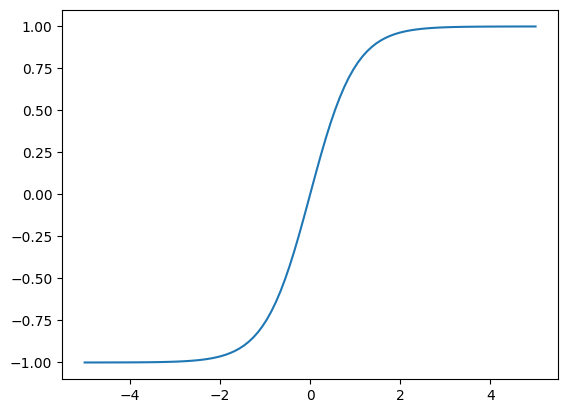

In [ ]:
x = torch.linspace(-5, 5, 100)
y = torch.tanh(x)
plt.plot(x, y)

When $x < -2$ or $x > 2$, the $\tanh$ function starts flattening towards 0.0.

In [ ]:
for x in [-4, -2, 2, 4]:
  print(f"tanh({x}) = {torch.tanh(torch.tensor(x))}")

tanh(-4) = -0.9993293285369873
tanh(-2) = -0.9640275835990906
tanh(2) = 0.9640275835990906
tanh(4) = 0.9993293285369873


Now its gradient:

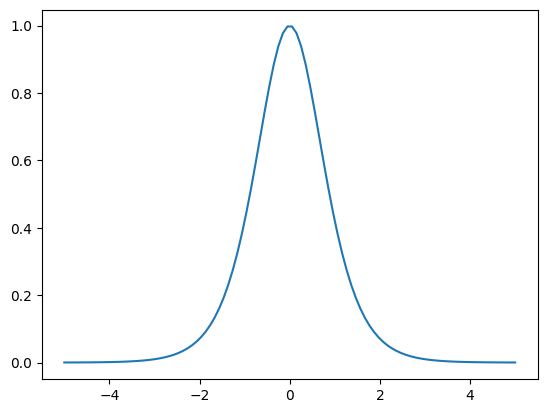

In [ ]:
x = torch.linspace(-5, 5, 100)
y = 1 - torch.pow(torch.tanh(x), 2)
plt.plot(x, y)

Here we confirm our interpretation. The gradient is at its max when X = 0, and at starts approach zero at [-2, 2] and then is pretty much zero when outside [-4, 4]:

In [ ]:
for x in [-4, -2, 2, 4]:
  print(f"grad(tanh({x})) = {1 - torch.pow(torch.tanh(torch.tensor(x)), 2)}")

grad(tanh(-4)) = 0.0013408660888671875
grad(tanh(-2)) = 0.07065081596374512
grad(tanh(2)) = 0.07065081596374512
grad(tanh(4)) = 0.0013408660888671875


## Tanh layers - no init

      1/      1: 3.570092


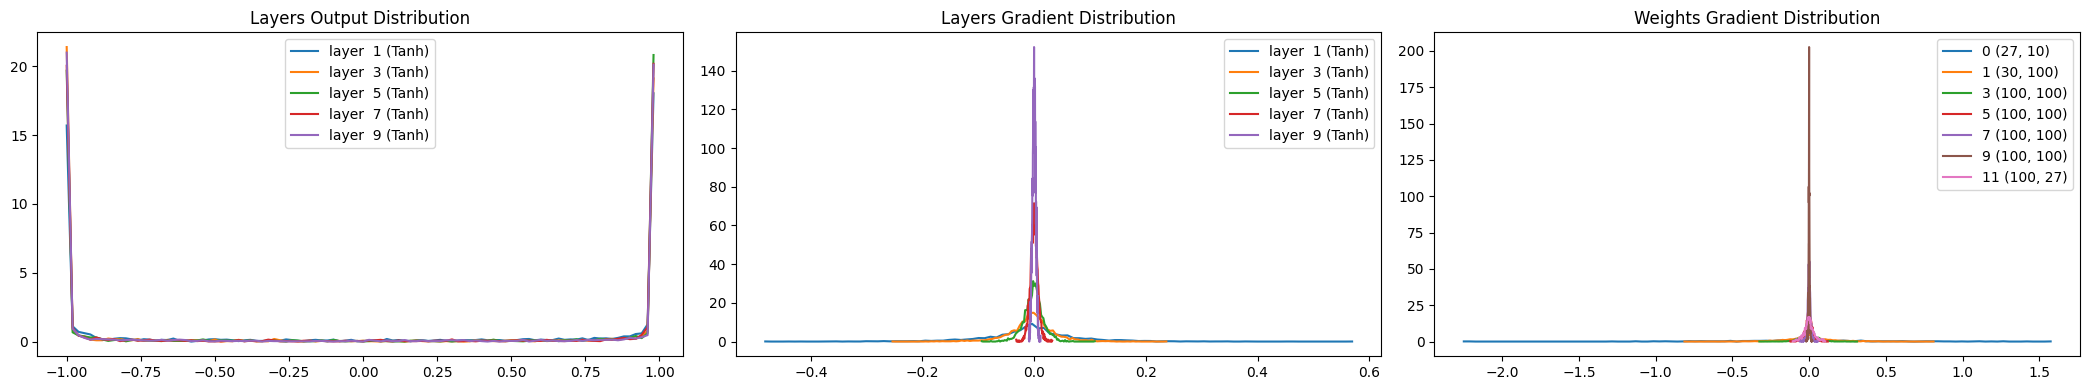

##### 
layer  1 (Tanh): mean = 0.054807 | std = 0.922250 | saturated =  70.22%
layer  3 (Tanh): mean = -0.050687 | std = 0.957487 | saturated =  83.03%
layer  5 (Tanh): mean = 0.019241 | std = 0.957496 | saturated =  82.47%
layer  7 (Tanh): mean = 0.001258 | std = 0.958458 | saturated =  82.53%
layer  9 (Tanh): mean = -0.032083 | std = 0.959339 | saturated =  83.91%
##### 
layer  1 (Tanh): mean = 0.000307 | std = 0.088533
layer  3 (Tanh): mean = -0.001651 | std = 0.041987
layer  5 (Tanh): mean = 0.000065 | std = 0.017419
layer  7 (Tanh): mean = 0.000197 | std = 0.006974
layer  9 (Tanh): mean = 0.000083 | std = 0.003047
##### 
weight 0 (27, 10) | mean = -0.014062 | std = 4.687555e-01 | grad:data ratio = 4.678859e-01
weight 1 (30, 100) | mean = +0.000786 | std = 1.656899e-01 | grad:data ratio = 1.658187e-01
weight 3 (100, 100) | mean = -0.000035 | std = 5.146886e-02 | grad:data ratio = 5.179159e-02
weight 5 (100, 100) | mean = -0.000398 | std = 2.612798e-02 | grad:data ratio = 2.611336e-

In [ ]:
plot_model_graphs(1, Tanh, init_gain=None) # TODO: set initialization type = None



This table now includes the specified values for "Tanh layers - no init" experiment. Let me know if you'd like to modify or add any other information!

Experiment name: Tanh layers - no init
Loss: 1
Stable Output: ✅
Uniform Act. Sat.: ✅
Acceptable Act. Sat: ❌
Stable Layer Gradients: ❌
Stable Weight Gradients: ❌
Optimal Update/Data Ratio: ❌
Uniform Update/Data Ratio: ❌

For this experiment `Tanh layers - no init`, after 1 training step, we can conclude the following:

**Outputs:**
- ❌ All tanh layers are very saturated. Without any weight initialization, weights are sampled from a standard normal distribution, meaning that their range will be [-3,3] most of the time. Meaning there is a high likelihood that weights will boost values beyond the range where tanh starts squeezing them. For this reason, we see high saturation across all layers. For one, by default, from the start, most inputs are being mostly squashed into ttwo values, -1 or 1, meaning we're losing signal in the forward pass.

**Tanh Layer Gradients:**
- ❌ Gradients become bigger as they backpropagate. This is because the values become smaller as they feed forward. Ideally we would have a similar gradient distribution across layers.

**Weights Gradients:**
- ❌ The same pattern is happening with the weight gradients, where they get bigger as they are backpropagated. Also, the gradients should be three orders of magnitude smaller than the data they're updating. Here they are too big, just one or two orders of magnitude smaller.

**Conclusion:**
- ❌ Bad starting state. The extreme tanh activations are a bad sign, if the model doesn't balance it out with more steps, learning will be quite slow.

Let's run longer:

      1/  10000: 3.570092
  10000/  10000: 2.594262


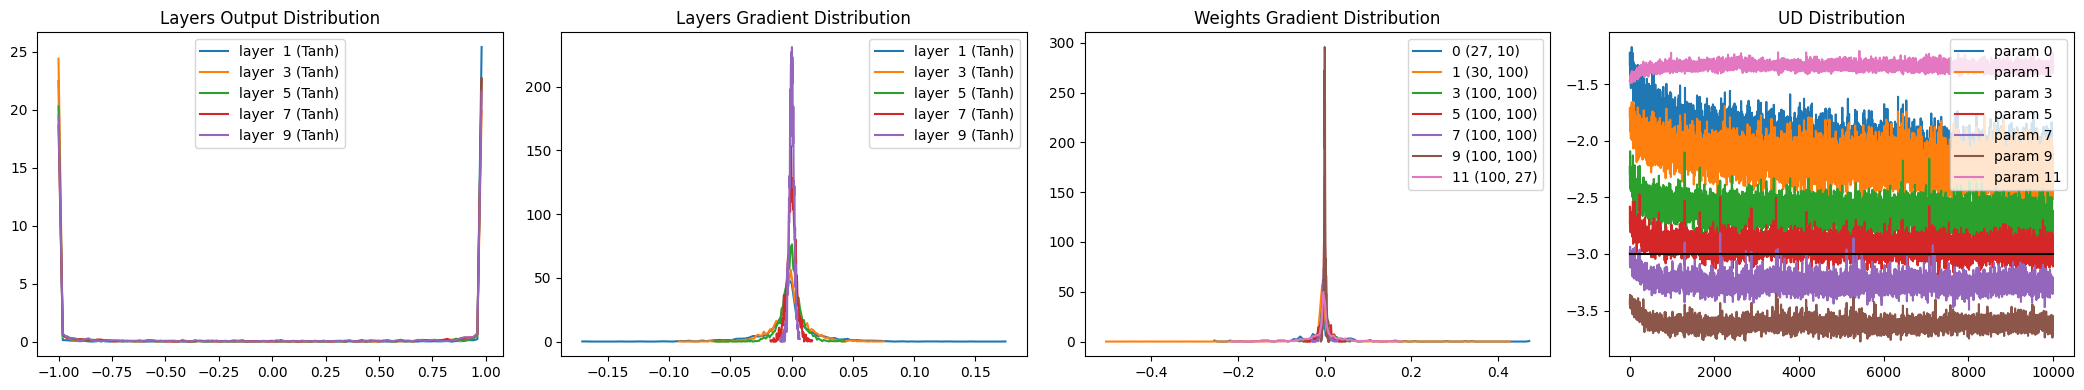

##### 
layer  1 (Tanh): mean = 0.061384 | std = 0.989460 | saturated =  96.16%
layer  3 (Tanh): mean = -0.083212 | std = 0.974388 | saturated =  89.78%
layer  5 (Tanh): mean = 0.044168 | std = 0.969247 | saturated =  87.19%
layer  7 (Tanh): mean = 0.088451 | std = 0.957393 | saturated =  84.28%
layer  9 (Tanh): mean = 0.049157 | std = 0.959314 | saturated =  83.69%
##### 
layer  1 (Tanh): mean = -0.000396 | std = 0.023553
layer  3 (Tanh): mean = -0.000150 | std = 0.014629
layer  5 (Tanh): mean = 0.000091 | std = 0.008751
layer  7 (Tanh): mean = 0.000079 | std = 0.003912
layer  9 (Tanh): mean = 0.000063 | std = 0.002016
##### 
weight 0 (27, 10) | mean = +0.001285 | std = 7.367799e-02 | grad:data ratio = 3.668261e-02
weight 1 (30, 100) | mean = -0.001423 | std = 4.219174e-02 | grad:data ratio = 3.225965e-02
weight 3 (100, 100) | mean = +0.000006 | std = 1.311232e-02 | grad:data ratio = 1.280033e-02
weight 5 (100, 100) | mean = +0.000103 | std = 8.664236e-03 | grad:data ratio = 8.603130e-

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=None) # TODO: set initialization type = None, TODO: replace 10000 -> 10_000

For this experiment `Tanh layers - no init`, after $10k$ training steps, we can conclude the following:

Here is the table formatted with the data you provided:

| Experiment   | Loss | Stable Output Prop. | Uniform Act. Sat. | Acceptable Act. Sat. | Stable Tanh Gradients | Stable Weight Gradients | Optimal Update/Data Ratio | Uniform Update/Data Ratio |
|--------------|------|---------------------|-------------------|----------------------|-----------------------|-------------------------|---------------------------|---------------------------|
| Tanh layers - no init | 2.59    | ✅                   | ✅                 | ❌                    | ❌                     | ❌                       | ❌                         | ❌                         |

**Outputs:**
- ❌ Tanh activations remain very saturated, curiously the first layer even worsened.

**Tanh Layer Gradients:**
- ❌ Gradients are still growing as they backpropagate.

**Weights Gradients:**
- ❌ Gradients are still growing as they backpropagate.

**Update/Data Ratio:**

- ❌ Layers are learning at very different rates, the magnitude of their updates in respect to their data is very high for some, and lower for others. The output layer is an outlier because it starts with an handicap where we artificially shrink the weights at initialization to force a uniform distribution in the output, which is the optimal starting state for the problem we're modeling. In a normal scenario, the model would start with big updates to sort out this handicap but start converging to a much smaller ratio with time, this isn't happening, which is indicative of the model not learning properly.

**Conclusion:**
- ❌ The model is failing to learn.

Let's log the result of this experiment:

| Experiment            | Loss |
|---------------------- |---------------|
| **Tanh layers - no init** | **2.88**    |

## Tanh layers - no init + batch norm

      1/      1: 3.284986


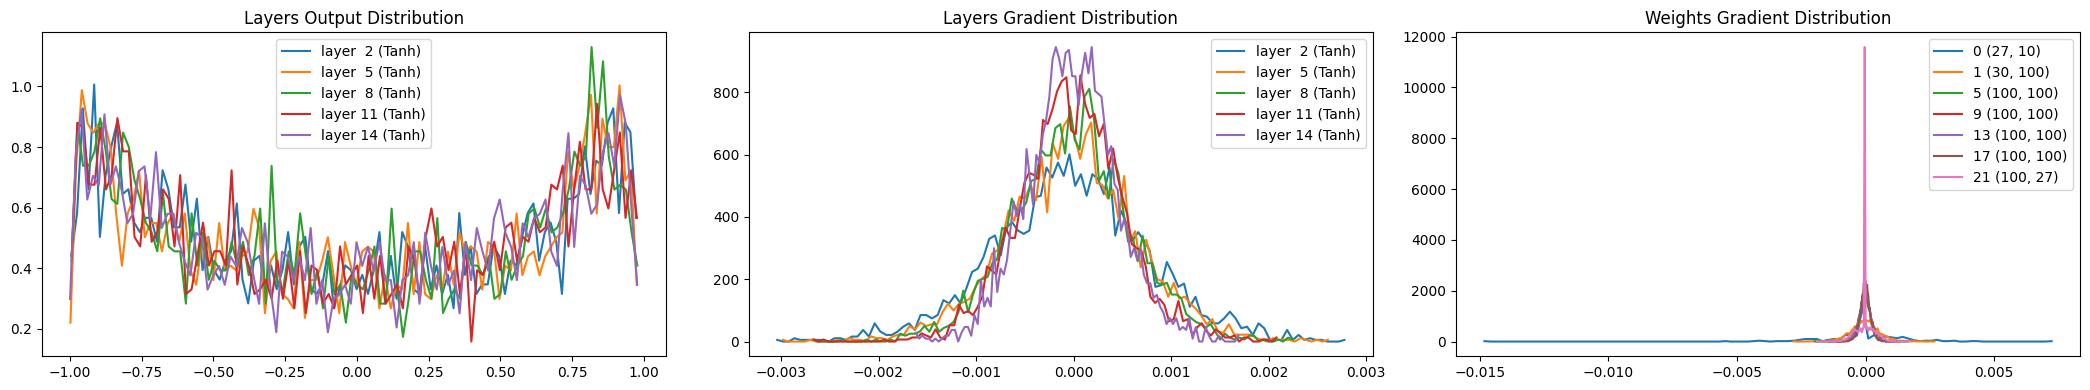

##### 
layer  2 (Tanh): mean = -0.005781 | std = 0.636437 | saturated =   2.25%
layer  5 (Tanh): mean = 0.000413 | std = 0.638783 | saturated =   2.22%
layer  8 (Tanh): mean = 0.000681 | std = 0.640065 | saturated =   2.47%
layer 11 (Tanh): mean = 0.000004 | std = 0.638397 | saturated =   2.69%
layer 14 (Tanh): mean = 0.001923 | std = 0.636571 | saturated =   2.44%
##### 
layer  2 (Tanh): mean = -0.000000 | std = 0.000801
layer  5 (Tanh): mean = -0.000000 | std = 0.000677
layer  8 (Tanh): mean = -0.000000 | std = 0.000603
layer 11 (Tanh): mean = 0.000000 | std = 0.000535
layer 14 (Tanh): mean = 0.000000 | std = 0.000457
##### 
weight 0 (27, 10) | mean = -0.000000 | std = 1.718046e-03 | grad:data ratio = 1.716588e-03
weight 1 (30, 100) | mean = -0.000000 | std = 5.814903e-04 | grad:data ratio = 5.820221e-04
weight 5 (100, 100) | mean = +0.000000 | std = 2.818657e-04 | grad:data ratio = 2.836374e-04
weight 9 (100, 100) | mean = -0.000001 | std = 2.616007e-04 | grad:data ratio = 2.614553e

In [ ]:
plot_model_graphs(1, Tanh, init_gain=None, batch_norm=True) # TODO: set initialization type = None

For this experiment `Tanh layers - no init + batch norm`, after 1 training step, we can conclude the following:

**Outputs:**
- ✅ Before using batch normalizatino, all tanh layers were very saturated from the start. This is no longer the case, saturation starts low but evenly distributed across layers.

**Tanh Layer Gradients:**
- ✅ Beforehand, gradients were not stable, they grew as they backpropagated. They are now stable and similar all layers.

**Weights Gradients:**
- ❌ Weight gradient standard deviation is now stable during backpropagation.
Also, the ratio of gradients to the data they're updating is decent,but perhaps a bit too low.

**Conclusion:**
- ✅ Batch normalization seems to have mitigated the issues caused by not performing any model initialization.

Let's run longer:

      1/  10000: 3.284986
  10000/  10000: 2.110316


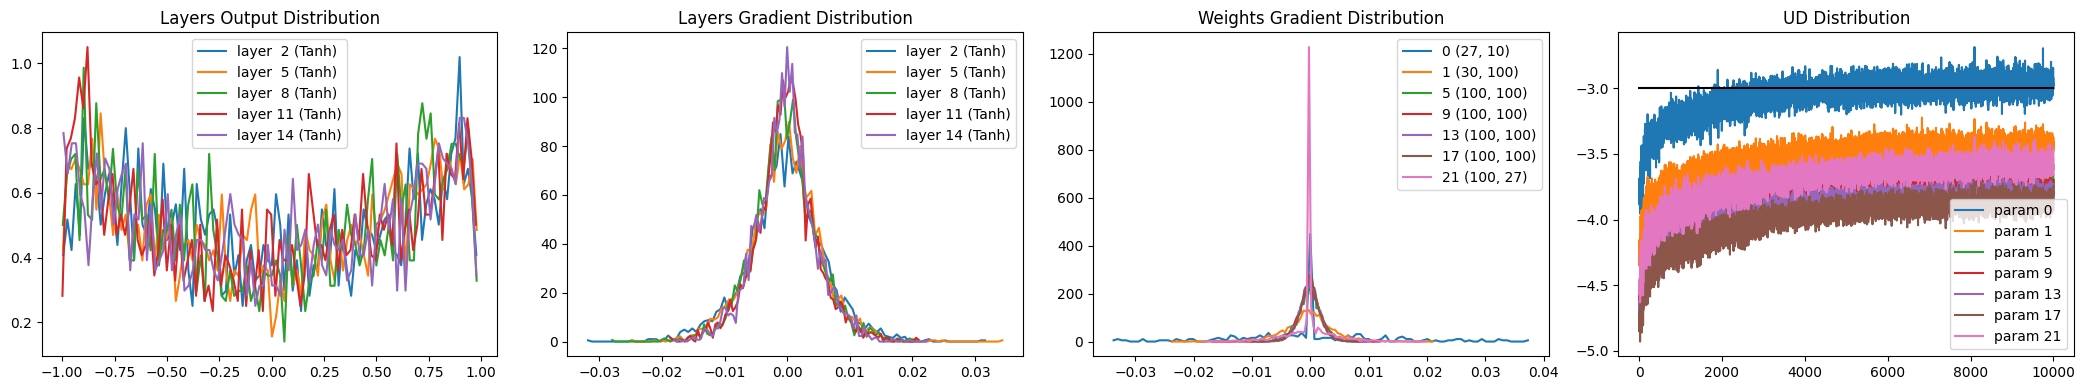

##### 
layer  2 (Tanh): mean = 0.001437 | std = 0.613768 | saturated =   2.06%
layer  5 (Tanh): mean = 0.020132 | std = 0.624446 | saturated =   2.81%
layer  8 (Tanh): mean = 0.007526 | std = 0.631047 | saturated =   2.53%
layer 11 (Tanh): mean = -0.000981 | std = 0.629211 | saturated =   2.44%
layer 14 (Tanh): mean = 0.008394 | std = 0.623762 | saturated =   2.84%
##### 
layer  2 (Tanh): mean = -0.000000 | std = 0.006220
layer  5 (Tanh): mean = 0.000000 | std = 0.005541
layer  8 (Tanh): mean = 0.000000 | std = 0.005113
layer 11 (Tanh): mean = 0.000000 | std = 0.004823
layer 14 (Tanh): mean = -0.000000 | std = 0.004674
##### 
weight 0 (27, 10) | mean = -0.000000 | std = 1.191660e-02 | grad:data ratio = 1.185378e-02
weight 1 (30, 100) | mean = -0.000038 | std = 4.176860e-03 | grad:data ratio = 4.178554e-03
weight 5 (100, 100) | mean = +0.000045 | std = 2.164197e-03 | grad:data ratio = 2.177520e-03
weight 9 (100, 100) | mean = +0.000009 | std = 1.986035e-03 | grad:data ratio = 1.984736e-

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=None, batch_norm=True) # TODO: set initialization type = None

For this experiment `Tanh layers - no init + batch norm`, after $10k$ training steps, we can conclude the following:

**Outputs:**
- ✅ Tanh saturations remain consistent with first training step, low and consistent across layers.

**Tanh Layer Gradients:**
- ✅ Gradients remain stable during backpropagation, with a minor increase in value as they get backpropagated. Their standard deviation has increased by an order of magnitude when compared to first step.

**Weights Gradients:**
- ✅ Like in the tahn layers, gradients exhibit the same pattern, stable across layers, slighly increasing as they move to the first layers. Their standard deviation has also increased by an order of magnitude when compared to the first step, the gradient to data ratio as also increased by an order of magnitude making it more indicative of the model picking up the learning pace.

**Update/Data Ratio:**

- ❌ All layers except the first one are learning at a slow rate. As can be seen in the *UD Distribution* graph, the ratio of updates to the data being updated is below the optimal of 1**-3 for most layers.

**Conclusion:**
- ❌ The mitigation that happened at initializtaion has lasted through training with training being very stable and resulting in a much better loss than not having used batch normalization. However, the model is learning slower than it could.

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| **Tanh layers - no initialization + batch normalization** | **2.11**    |

Let's try increasing the learning rate to fix the issue of the layers learning slowly:

      1/  10000: 3.284986
  10000/  10000: 2.211518


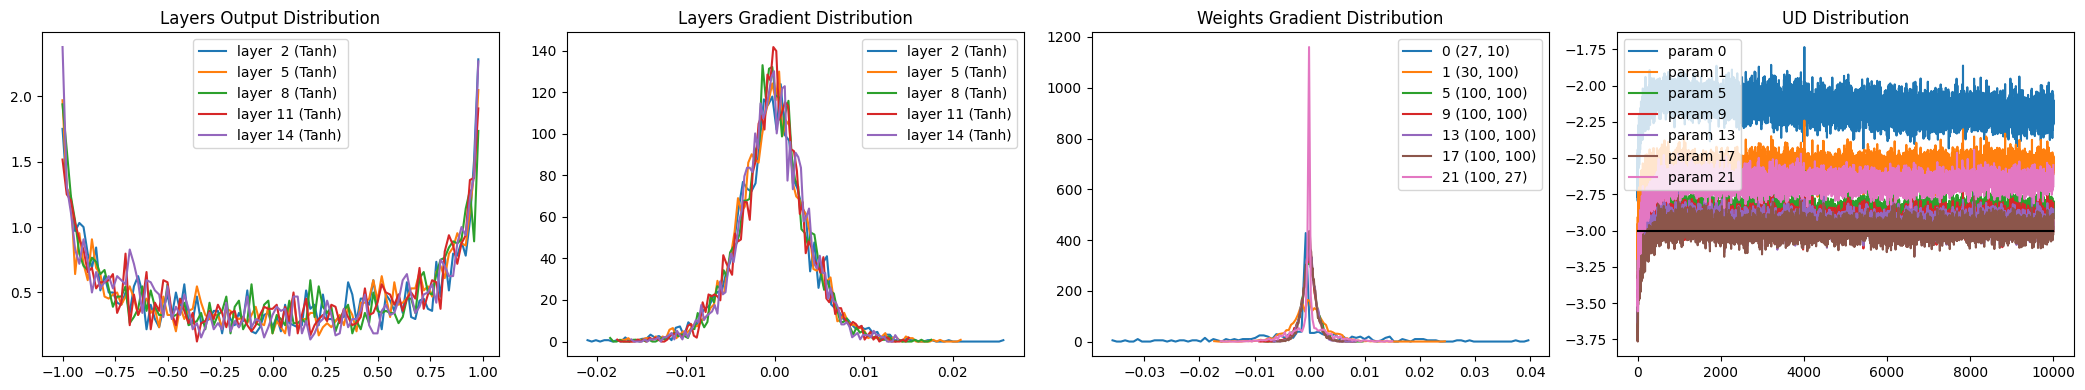

##### 
layer  2 (Tanh): mean = -0.002366 | std = 0.697590 | saturated =  11.47%
layer  5 (Tanh): mean = 0.026947 | std = 0.699295 | saturated =  11.19%
layer  8 (Tanh): mean = -0.003136 | std = 0.697211 | saturated =   9.72%
layer 11 (Tanh): mean = 0.021022 | std = 0.695286 | saturated =   9.75%
layer 14 (Tanh): mean = -0.016908 | std = 0.708606 | saturated =  12.06%
##### 
layer  2 (Tanh): mean = 0.000000 | std = 0.004328
layer  5 (Tanh): mean = -0.000000 | std = 0.004115
layer  8 (Tanh): mean = 0.000000 | std = 0.003850
layer 11 (Tanh): mean = -0.000000 | std = 0.003852
layer 14 (Tanh): mean = 0.000000 | std = 0.003777
##### 
weight 0 (27, 10) | mean = +0.000000 | std = 1.035457e-02 | grad:data ratio = 7.892758e-03
weight 1 (30, 100) | mean = -0.000014 | std = 3.370479e-03 | grad:data ratio = 3.251201e-03
weight 5 (100, 100) | mean = +0.000011 | std = 1.600233e-03 | grad:data ratio = 1.596323e-03
weight 9 (100, 100) | mean = -0.000029 | std = 1.562457e-03 | grad:data ratio = 1.551090

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=None, batch_norm=True, learning_rate=LEARNING_RATE*10)

TODO: WHY THE WORSE LOSS?

With a 10x learning rate we got a better loss. There are some noticeable patterns that justify it:

**Outputs:**
- Output standard deviation has increased resulting in higher tanh saturation, yet these patterns are stable across all layers. It seems that the model has learned faster to leverage the non-linearity in order to produce a lower loss.

**UD Distribution**:
- All layers are now learning at a good rate, with the initial layer performing updates with the highest magnitude.

Due to this conclusion, whenever we try batch norm going forward, we are going to 10x the learning rate, unless we need to adjust it again if we notice an issue in the UD distribuution.

Let's log the results:

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| **Tanh layers - no init + batch norm + 10x learning rate** | **2.21**    |


## Tanh layers - optimal init gain

Let's analyze the model when we use the proper init gain for tanh of 5/3:

      1/      1: 3.294214


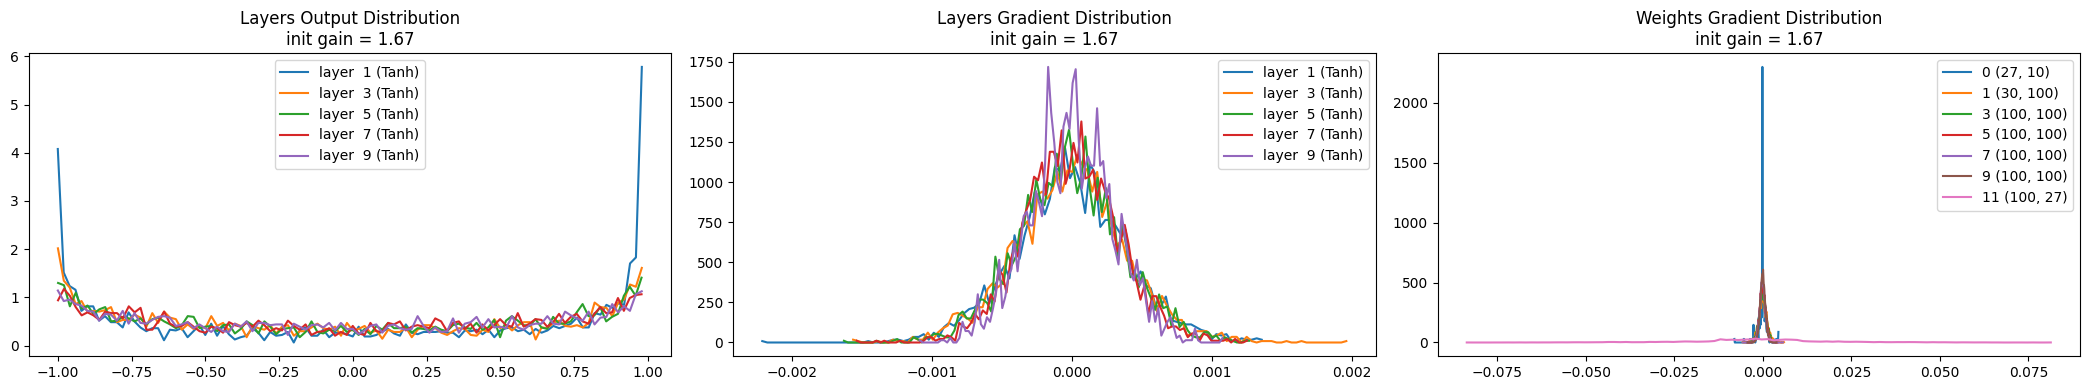

##### Layers Output Distribution (init gain = 1.67)
layer  1 (Tanh): mean = 0.048971 | std = 0.764594 | saturated =  23.41%
layer  3 (Tanh): mean = -0.040694 | std = 0.689942 | saturated =   9.84%
layer  5 (Tanh): mean = -0.002841 | std = 0.673670 | saturated =   7.75%
layer  7 (Tanh): mean = 0.004849 | std = 0.658775 | saturated =   6.31%
layer  9 (Tanh): mean = -0.007656 | std = 0.652034 | saturated =   6.72%
##### Layers Gradient Distribution (init gain = 1.67)
layer  1 (Tanh): mean = 0.000008 | std = 0.000404
layer  3 (Tanh): mean = 0.000006 | std = 0.000401
layer  5 (Tanh): mean = -0.000002 | std = 0.000373
layer  7 (Tanh): mean = 0.000003 | std = 0.000339
layer  9 (Tanh): mean = 0.000007 | std = 0.000299
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = -0.000037 | std = 1.330358e-03 | grad:data ratio = 1.329231e-03
weight 1 (30, 100) | mean = +0.000033 | std = 1.246278e-03 | grad:data ratio = 4.099436e-03
weight 3 (100, 100) | mean = -0.000013 | s

In [ ]:
plot_model_graphs(1, Tanh, init_gain=5/3)

For this experiment `Tanh layers - optimal init gain`, after 1 training step, we can conclude the following:

**Outputs:**
- ✅ Well-distributed values across the $tanh$ range of $[-1, 1]$.
- ✅ Stable standard deviation across layers, ensuring smooth signal propagation.
- ✅ Healthy $tanh$ saturation: values avoid gradient dead zones, with controlled saturation allowing non-linear expressivity.
- ✅ Slightly higher saturation in the first layer, decreasing as $tanh$ compresses values into $[-1, 1]$. Strong weights still push some values to extremes, though limited.

**Tanh Layer Gradients:**
- ✅ Similar gradient distribution across layers, ensuring effective backpropagation and a solid start for learning.

**Weights Gradients:**
- ❌ Gradients smaller than weights, except in the last layer where they match in scale, this is caused by the output layer weight squeeze.
- ❌ Output layer gradients are about $100x$ larger than earlier layers.

**Conclusion:**
- ✅ Good initial activation and gradient flow.
- ❌ Large weights and gradient-to-weight ratio in the last layer suggest possible instability, needing further analysis.

Let's see if the issue we detected in the last layer goes away with further training:

      1/  10000: 3.294214
  10000/  10000: 1.992995


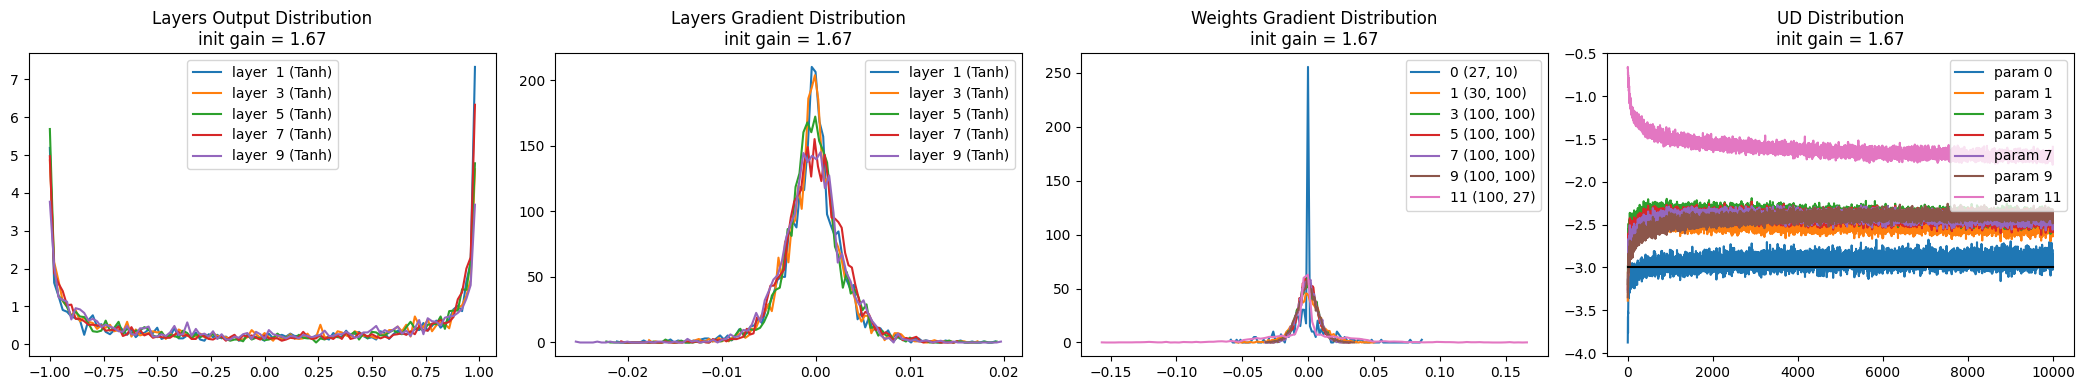

##### Layers Output Distribution (init gain = 1.67)
layer  1 (Tanh): mean = 0.054846 | std = 0.797435 | saturated =  29.12%
layer  3 (Tanh): mean = -0.033765 | std = 0.777342 | saturated =  23.16%
layer  5 (Tanh): mean = -0.012650 | std = 0.795869 | saturated =  25.75%
layer  7 (Tanh): mean = 0.025450 | std = 0.808969 | saturated =  27.38%
layer  9 (Tanh): mean = -0.040562 | std = 0.753879 | saturated =  18.84%
##### Layers Gradient Distribution (init gain = 1.67)
layer  1 (Tanh): mean = -0.000070 | std = 0.003354
layer  3 (Tanh): mean = -0.000063 | std = 0.003178
layer  5 (Tanh): mean = 0.000004 | std = 0.003125
layer  7 (Tanh): mean = 0.000107 | std = 0.003173
layer  9 (Tanh): mean = -0.000156 | std = 0.003370
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.000021 | std = 1.642675e-02 | grad:data ratio = 1.582852e-02
weight 1 (30, 100) | mean = +0.000345 | std = 1.128553e-02 | grad:data ratio = 3.431766e-02
weight 3 (100, 100) | mean = -0.000083 |

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=5/3)

For this experiment `Tanh layers - optimal init gain`, after $10k$ training steps, we can conclude the following:

**Outputs:**
- ✅ Non-linearity now appears across all layers. Initially, only the first layer showed $\tanh$ saturation, but now all layers exhibit mild saturation, indicating a stronger usage of its non-linear properties.

**Tanh Layer Gradients:**
- ✅ Gradient distribution remains consistent across layers, suggesting uniform learning speed across layers.
- ✅ Gradient standard deviation has increased, reflecting dynamic weight adjustments during training.

**Weight Gradients:**
- ✅ The earlier weight discrepancy in the last layer has significantly reduced, showing the model is correcting the output layer imbalance.

**Update/Data Ratios:**
- ✅ Most layers update with magnitudes $1000$ times smaller than their parameter values, a healthy ratio.
- ✅ Output layer update ratio starts large but shrinks as initial weight capping is resolved. -- TODO

**Conclusion:**
- ✅ The model is leveraging non-linearities more effectively.
- ✅ Gradient flow remains stable.
- ✅ The weight imbalance in the output layer is resolving.
- ✅ Overall, the training process is going well as the model is learning effectively.

Let's log the results:

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| Tanh layers - no init + batch norm + 10x learning rate | 2.21    |
| **Tanh layers - optimal init gain** | **1.99**    |


## Tanh layers - optimal init gain + batch norm

      1/      1: 3.284986


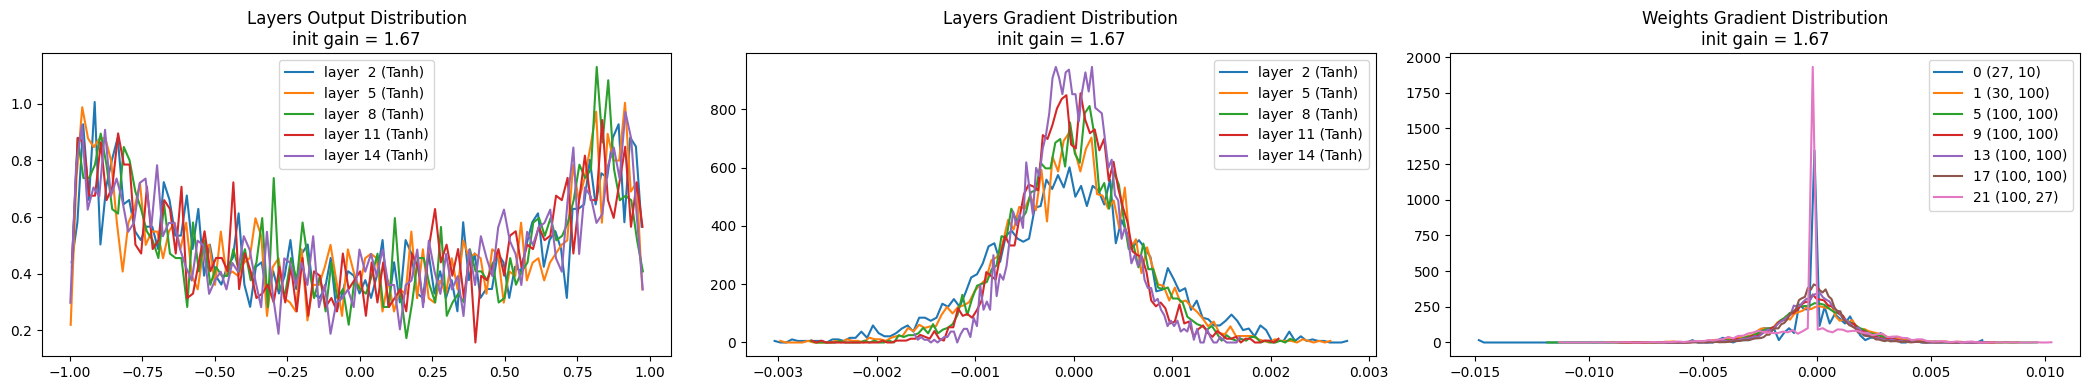

##### Layers Output Distribution (init gain = 1.67)
layer  2 (Tanh): mean = -0.005781 | std = 0.636437 | saturated =   2.25%
layer  5 (Tanh): mean = 0.000413 | std = 0.638781 | saturated =   2.22%
layer  8 (Tanh): mean = 0.000681 | std = 0.640064 | saturated =   2.47%
layer 11 (Tanh): mean = 0.000004 | std = 0.638396 | saturated =   2.69%
layer 14 (Tanh): mean = 0.001923 | std = 0.636569 | saturated =   2.44%
##### Layers Gradient Distribution (init gain = 1.67)
layer  2 (Tanh): mean = 0.000000 | std = 0.000801
layer  5 (Tanh): mean = -0.000000 | std = 0.000677
layer  8 (Tanh): mean = -0.000000 | std = 0.000603
layer 11 (Tanh): mean = -0.000000 | std = 0.000535
layer 14 (Tanh): mean = 0.000000 | std = 0.000457
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.000000 | std = 1.718030e-03 | update:data ratio = 1.716572e-04
weight 1 (30, 100) | mean = -0.000000 | std = 1.910953e-03 | update:data ratio = 6.285774e-04
weight 5 (100, 100) | mean = +0.000001

In [ ]:
plot_model_graphs(1, Tanh, init_gain=5/3, batch_norm=True)

For this experiment `Tanh layers - optimal init gain + batch norm`, after $1$ training step, we can conclude the following:

**Outputs:**
- ✅ Stable tanh saturation, altough a bit low.

**Tanh Layer Gradients:**
- BAD - Stable gradients, although low and growing as they get backpropagated.


**Weight Gradients:**
- ✅ Stable gradients, growing as they get backrpopagated. Gradients are probably too big for the data they're updating, but not too bad.

**Conclusion:**
- ✅ Model seems stable at initialization and ready to learn.

Train longer:

      1/  10000: 3.284986
  10000/  10000: 2.035163


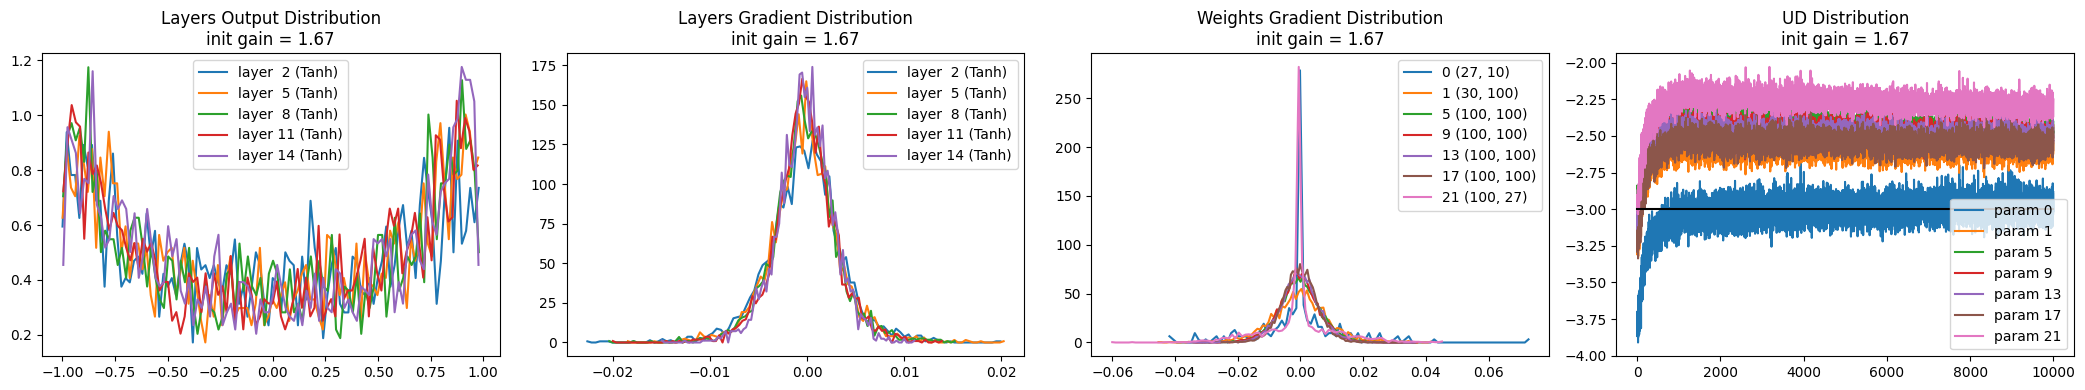

##### Layers Output Distribution (init gain = 1.67)
layer  2 (Tanh): mean = -0.009295 | std = 0.636067 | saturated =   4.03%
layer  5 (Tanh): mean = 0.003152 | std = 0.658958 | saturated =   4.16%
layer  8 (Tanh): mean = 0.001546 | std = 0.660490 | saturated =   3.56%
layer 11 (Tanh): mean = 0.011655 | std = 0.663143 | saturated =   3.72%
layer 14 (Tanh): mean = 0.013033 | std = 0.665293 | saturated =   3.03%
##### Layers Gradient Distribution (init gain = 1.67)
layer  2 (Tanh): mean = 0.000000 | std = 0.003963
layer  5 (Tanh): mean = -0.000000 | std = 0.003582
layer  8 (Tanh): mean = 0.000000 | std = 0.003412
layer 11 (Tanh): mean = 0.000000 | std = 0.003180
layer 14 (Tanh): mean = -0.000000 | std = 0.002811
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = -0.000000 | std = 1.315595e-02 | update:data ratio = 1.307892e-03
weight 1 (30, 100) | mean = +0.000190 | std = 9.615533e-03 | update:data ratio = 3.051230e-03
weight 5 (100, 100) | mean = +0.000084 

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=5/3, batch_norm=True)

The update to data ratios are decent, but from the UD graph its noticeable that the first layer is learning optimally while the others are learning at a much slower rate in comparison, lets just nudge the learning rate a bit to make them all be closer to the baseline:

      1/  10000: 3.284986
  10000/  10000: 1.960392


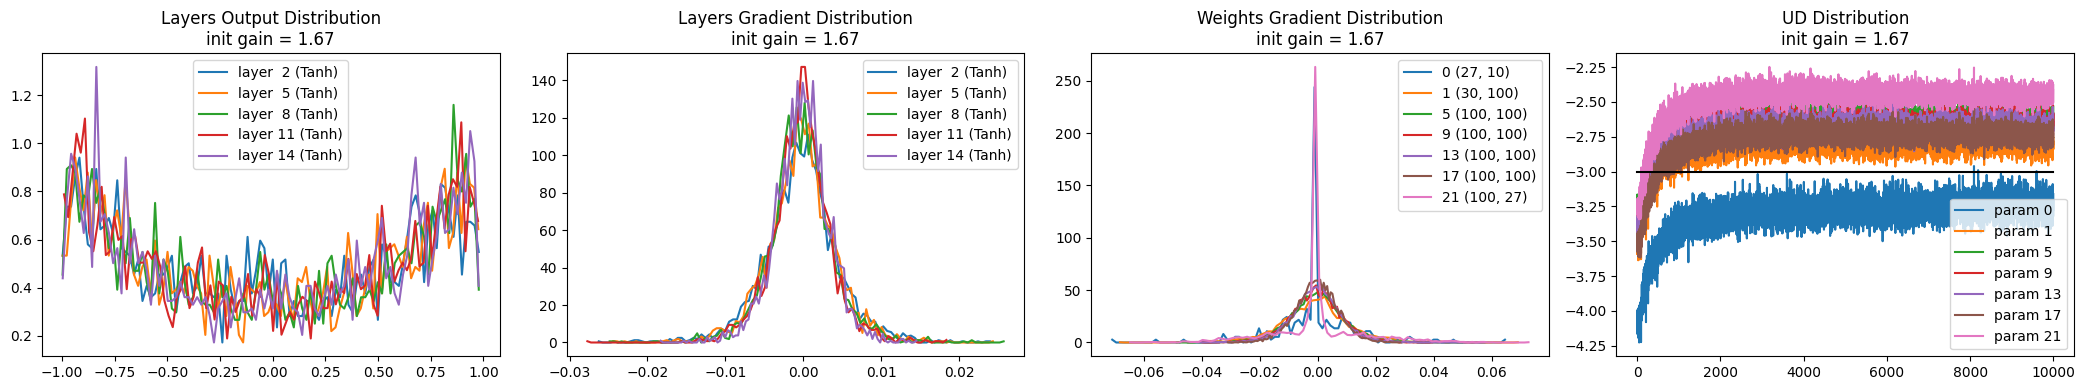

##### Layers Output Distribution (init gain = 1.67)
layer  2 (Tanh): mean = -0.006910 | std = 0.634332 | saturated =   2.97%
layer  5 (Tanh): mean = -0.000414 | std = 0.646478 | saturated =   2.97%
layer  8 (Tanh): mean = 0.001282 | std = 0.650355 | saturated =   2.94%
layer 11 (Tanh): mean = -0.000438 | std = 0.650425 | saturated =   3.19%
layer 14 (Tanh): mean = 0.011723 | std = 0.651540 | saturated =   2.84%
##### Layers Gradient Distribution (init gain = 1.67)
layer  2 (Tanh): mean = 0.000000 | std = 0.004865
layer  5 (Tanh): mean = 0.000000 | std = 0.004498
layer  8 (Tanh): mean = 0.000000 | std = 0.004141
layer 11 (Tanh): mean = 0.000000 | std = 0.003785
layer 14 (Tanh): mean = -0.000000 | std = 0.003435
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.000000 | std = 1.379632e-02 | update:data ratio = 6.882832e-04
weight 1 (30, 100) | mean = -0.000134 | std = 1.250989e-02 | update:data ratio = 2.032109e-03
weight 5 (100, 100) | mean = +0.000199

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=5/3, batch_norm=True, learning_rate=LEARNING_RATE * 0.5)

For this experiment `Tanh layers - optimal init gain + batch norm`, after $10k$ training steps, we can conclude the following:

**Outputs:**
- ✅ Stable saturation across layers.

**Tanh Layer Gradients:**
- ✅ Stable gradients across layers, growing as they get backpropagated, but within a healthy standard deviation.

**Weight Gradients:**
- ✅ Stable gradients, growing as they get backrpopagated. Updates may be a bit too big for the values they're updating.

**Conclusion:**
- ✅ Training is stable and model is learning well. The loss was worse than without batch norm however, but it could improve with a lower learning rate.

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| Tanh layers - no init + batch norm + 10x learning rate | 2.21    |
| Tanh layers - optimal init gain | 1.99    |
| **Tanh layers - optimal init gain + batch norm** | **1.96**    |

## Tanh layers - small init gain

Now let's analyze it when we use a small init gain of $1/2$ for 1 step:

      1/      1: 3.296049


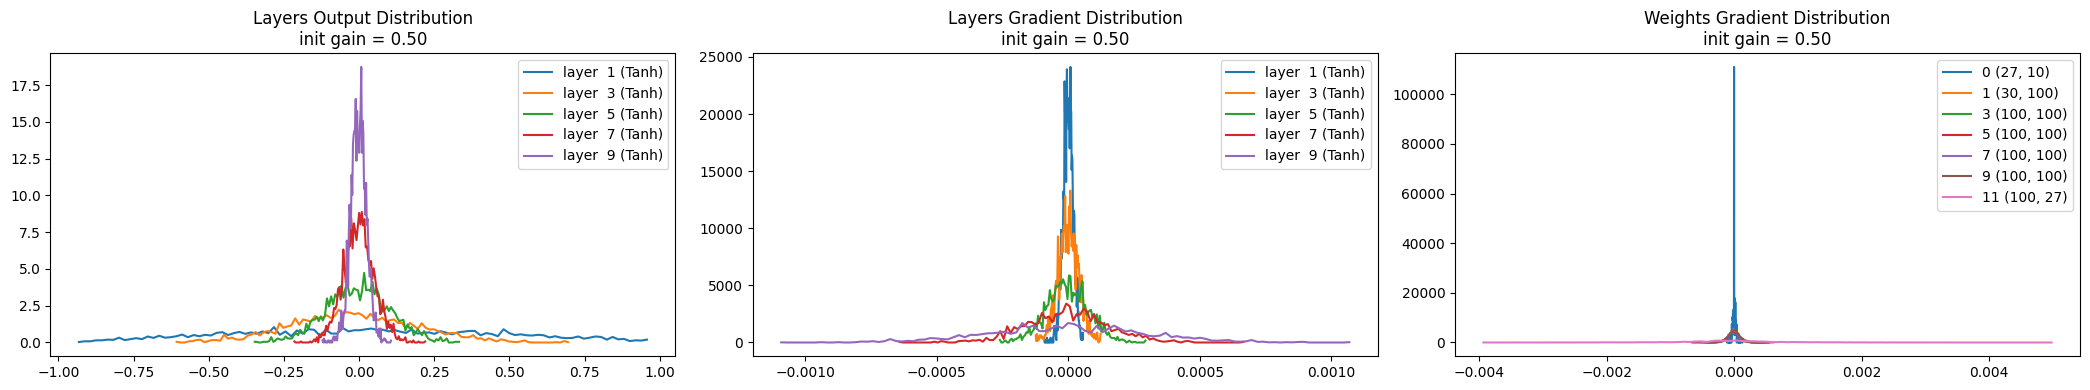

##### Layers Output Distribution (init gain = 0.50)
layer  1 (Tanh): mean = 0.036020 | std = 0.437542 | saturated =   0.12%
layer  3 (Tanh): mean = -0.011130 | std = 0.208314 | saturated =   0.00%
layer  5 (Tanh): mean = -0.000330 | std = 0.106098 | saturated =   0.00%
layer  7 (Tanh): mean = 0.001257 | std = 0.051833 | saturated =   0.00%
layer  9 (Tanh): mean = -0.000788 | std = 0.026631 | saturated =   0.00%
##### Layers Gradient Distribution (init gain = 0.50)
layer  1 (Tanh): mean = 0.000000 | std = 0.000019
layer  3 (Tanh): mean = 0.000002 | std = 0.000040
layer  5 (Tanh): mean = -0.000001 | std = 0.000081
layer  7 (Tanh): mean = 0.000003 | std = 0.000156
layer  9 (Tanh): mean = 0.000007 | std = 0.000299
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = +0.000001 | std = 2.791215e-05 | update:data ratio = 2.788848e-06
weight 1 (30, 100) | mean = -0.000001 | std = 9.606798e-05 | update:data ratio = 1.053335e-04
weight 3 (100, 100) | mean = +0.000000

In [ ]:
plot_model_graphs(1, Tanh, init_gain=1/2)

For this experiment `Tanh layers - small init gain`, after $1$ training step, we can conclude the following:

**Outputs:**
- ❌ Outputs shrink as they propagate forward through the layers, as $\tanh$ squeezes them into $[-1, 1]$, and the small gain further amplifies this shrinking effect.

**Tanh Layer Gradients:**
- ❌ Gradients are extremely small, with a standard deviation around $1e^{-4}$ (anything smaller than $1e^{-2}$ starts being too small).
- ❌ Vanishing gradients: Gradients diminish layer by layer during backpropagation, eventually reaching values as small as $1e^{-5}$ when they reach the first layer.

**Weights:**
- ❌ Last layer weight gradients are about $10x$ larger than in earlier layers.
**Conclusion:**
- ❌ The network will struggle to learn, as vanishing gradients impede backpropagation.
- ❌ Severe compression of values limits $\tanh$ activation, blocking necessary non-linear expressivity for learning.

Now let's train it longer:

      1/  10000: 3.296049
  10000/  10000: 2.144861


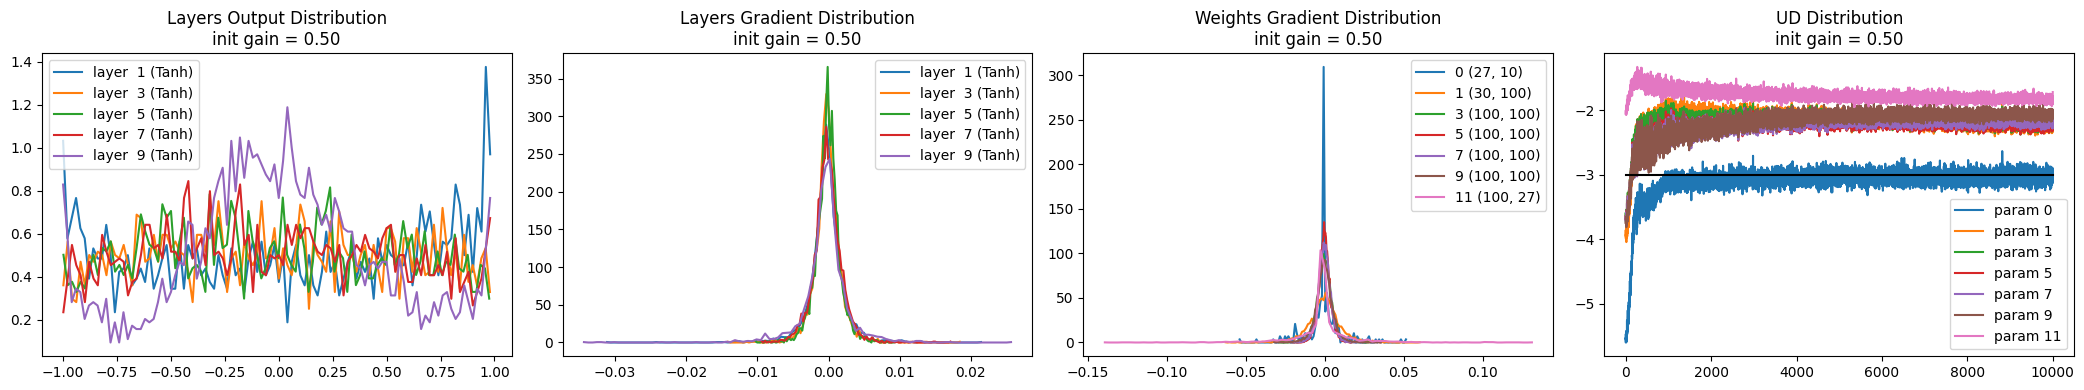

##### Layers Output Distribution (init gain = 0.50)
layer  1 (Tanh): mean = 0.042268 | std = 0.622371 | saturated =   5.78%
layer  3 (Tanh): mean = -0.000320 | std = 0.562527 | saturated =   2.19%
layer  5 (Tanh): mean = -0.011064 | std = 0.552683 | saturated =   2.00%
layer  7 (Tanh): mean = -0.008264 | std = 0.550756 | saturated =   2.69%
layer  9 (Tanh): mean = 0.009595 | std = 0.477270 | saturated =   4.62%
##### Layers Gradient Distribution (init gain = 0.50)
layer  1 (Tanh): mean = 0.000029 | std = 0.002611
layer  3 (Tanh): mean = 0.000014 | std = 0.001937
layer  5 (Tanh): mean = -0.000008 | std = 0.001735
layer  7 (Tanh): mean = 0.000002 | std = 0.002047
layer  9 (Tanh): mean = -0.000104 | std = 0.003258
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = -0.000066 | std = 1.144890e-02 | update:data ratio = 1.080516e-03
weight 1 (30, 100) | mean = +0.000221 | std = 1.058803e-02 | update:data ratio = 6.344695e-03
weight 3 (100, 100) | mean = +0.00006

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=1/2)

For this experiment `Tanh layers - small init gain`, after $10k$ training steps, we can conclude the following:

**Outputs**:
- Tanh saturation increased slightly

**Tanh Layer Gradients:**
- Gradient magnitudes have increased as well and stabilizied across layers.

**Weights Gradients:**
- Gradient weight distribution also stabilized.

**Update Data Ratio**:
- All layers are converging to a similar learning speed except the first layer which is struggling, this is caused by the vanishing gradient problem.

**Conclusion**:
- The small init gain is hampering the ability of the model to learn effectively.

Let's log the results:

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| Tanh layers - no init + batch norm + 10x learning rate | 2.21    |
| Tanh layers - optimal init gain | 1.99    |
| **Tanh layers - optimal init gain + batch norm** | **1.96**    |
| Tanh layers - small init gain | 2.14    |

## Tanh layers - small init gain + batch norm

      1/      1: 3.284987


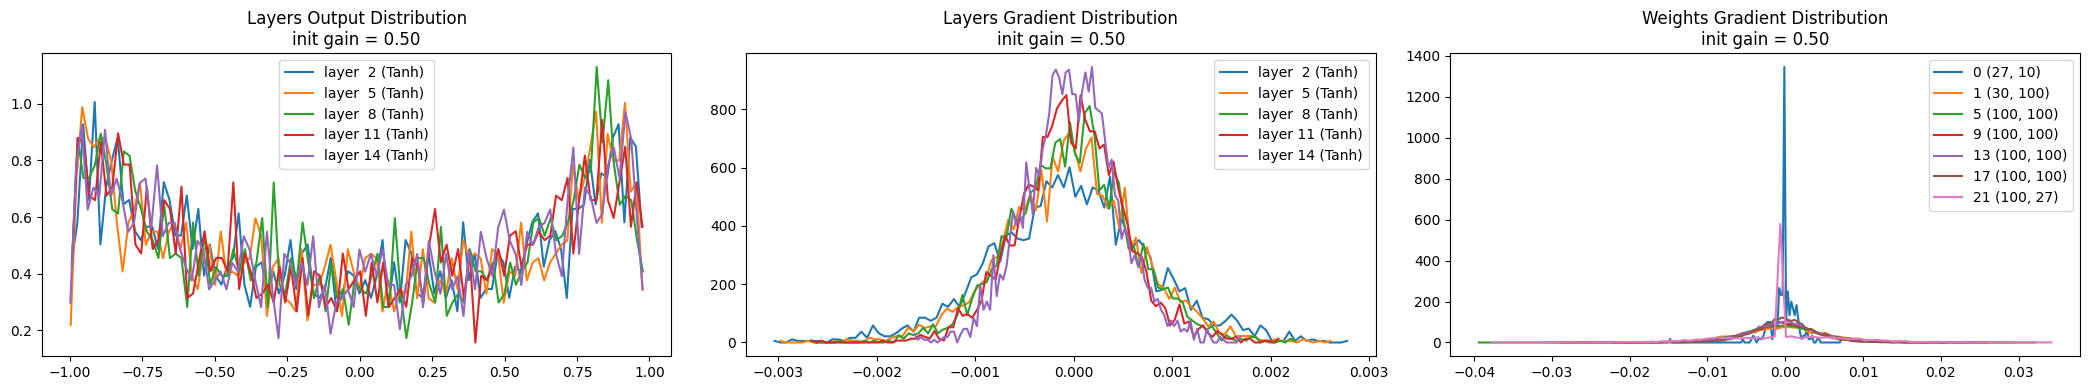

##### Layers Output Distribution (init gain = 0.50)
layer  2 (Tanh): mean = -0.005781 | std = 0.636430 | saturated =   2.25%
layer  5 (Tanh): mean = 0.000412 | std = 0.638764 | saturated =   2.22%
layer  8 (Tanh): mean = 0.000681 | std = 0.640048 | saturated =   2.47%
layer 11 (Tanh): mean = 0.000004 | std = 0.638379 | saturated =   2.69%
layer 14 (Tanh): mean = 0.001923 | std = 0.636553 | saturated =   2.44%
##### Layers Gradient Distribution (init gain = 0.50)
layer  2 (Tanh): mean = -0.000000 | std = 0.000801
layer  5 (Tanh): mean = -0.000000 | std = 0.000677
layer  8 (Tanh): mean = 0.000000 | std = 0.000603
layer 11 (Tanh): mean = 0.000000 | std = 0.000535
layer 14 (Tanh): mean = 0.000000 | std = 0.000457
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = +0.000000 | std = 1.717862e-03 | grad:data ratio = 1.716405e-03
weight 1 (30, 100) | mean = -0.000000 | std = 6.369179e-03 | grad:data ratio = 6.983296e-02
weight 5 (100, 100) | mean = +0.000003 | st

In [ ]:
plot_model_graphs(1, Tanh, init_gain=1/2, batch_norm=True)

For this experiment `Tanh layers - small init gain + batch norm`, after $1$ training step, we can conclude the following:

**Outputs**:
- Tanh saturation is stable across layers.

**Tanh Layer Gradients:**
- Gradients are stable across layers.

**Weights Gradients:**
- Gradients are stable across layers.

**Update Data Ratio**:
- Ratios are a bit too high.

**Conclusion**:
- Model is stable and should learn effectively.

Now longer:

      1/  10000: 3.284987
  10000/  10000: 2.088604


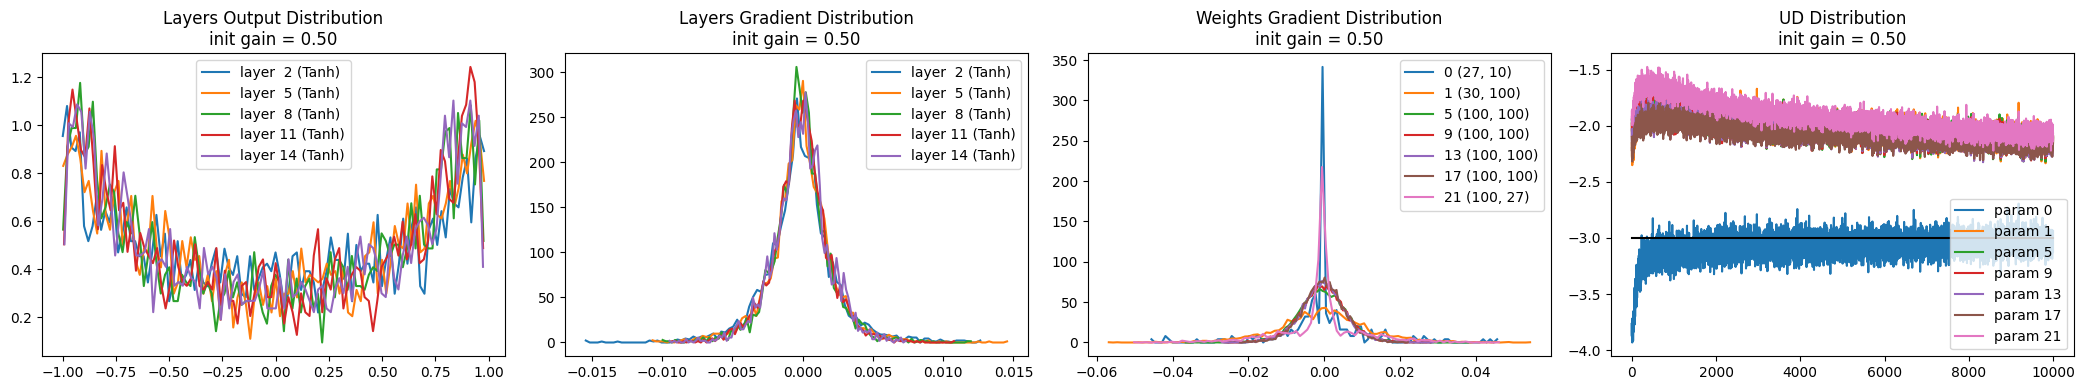

##### Layers Output Distribution (init gain = 0.50)
layer  2 (Tanh): mean = -0.009668 | std = 0.648283 | saturated =   5.47%
layer  5 (Tanh): mean = -0.000088 | std = 0.665464 | saturated =   4.75%
layer  8 (Tanh): mean = 0.001501 | std = 0.675818 | saturated =   3.25%
layer 11 (Tanh): mean = 0.001155 | std = 0.675853 | saturated =   2.78%
layer 14 (Tanh): mean = 0.000526 | std = 0.673915 | saturated =   2.25%
##### Layers Gradient Distribution (init gain = 0.50)
layer  2 (Tanh): mean = 0.000000 | std = 0.002595
layer  5 (Tanh): mean = 0.000000 | std = 0.002268
layer  8 (Tanh): mean = -0.000000 | std = 0.002059
layer 11 (Tanh): mean = 0.000000 | std = 0.001973
layer 14 (Tanh): mean = -0.000000 | std = 0.001974
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = -0.000000 | std = 1.153295e-02 | update:data ratio = 1.147963e-03
weight 1 (30, 100) | mean = +0.000246 | std = 1.228548e-02 | update:data ratio = 7.978857e-03
weight 5 (100, 100) | mean = -0.000064

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=1/2, batch_norm=True)

There is a big discraMost layers are learning too fast, by lowering the learning rate we should get better results:

      1/  10000: 3.284987
  10000/  10000: 2.022344


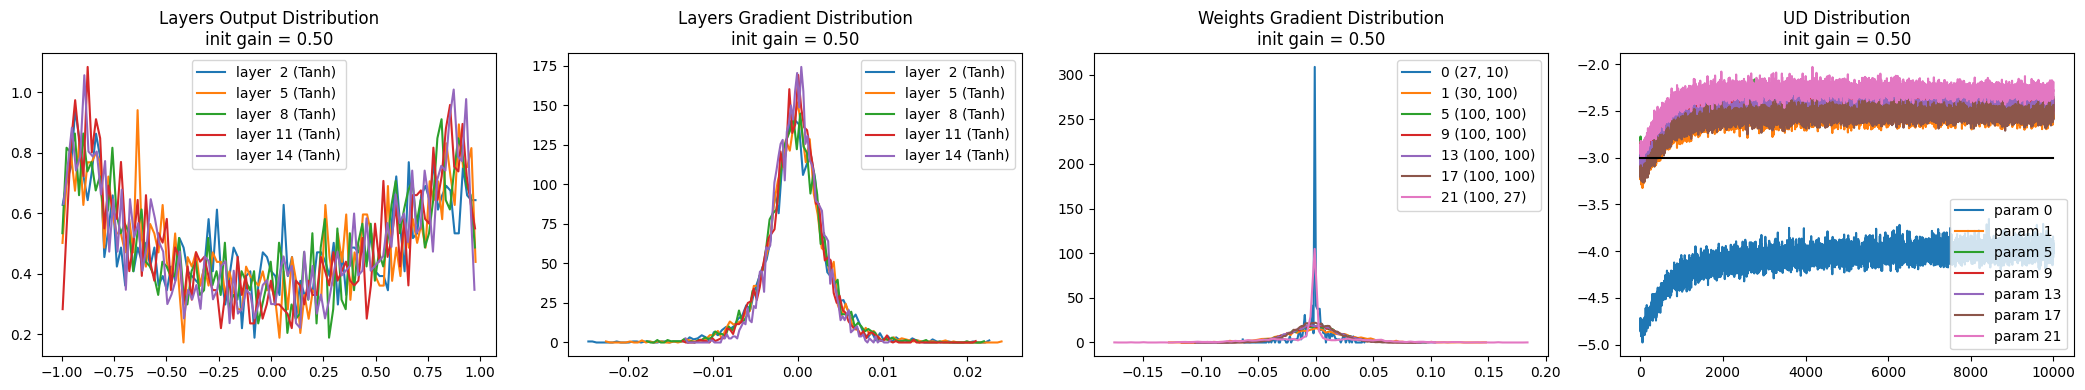

##### Layers Output Distribution (init gain = 0.50)
layer  2 (Tanh): mean = 0.001410 | std = 0.629509 | saturated =   3.25%
layer  5 (Tanh): mean = -0.003860 | std = 0.637004 | saturated =   3.12%
layer  8 (Tanh): mean = 0.005942 | std = 0.641103 | saturated =   2.72%
layer 11 (Tanh): mean = -0.002204 | std = 0.648979 | saturated =   2.16%
layer 14 (Tanh): mean = 0.005328 | std = 0.647367 | saturated =   2.41%
##### Layers Gradient Distribution (init gain = 0.50)
layer  2 (Tanh): mean = 0.000000 | std = 0.003879
layer  5 (Tanh): mean = 0.000000 | std = 0.003696
layer  8 (Tanh): mean = 0.000000 | std = 0.003621
layer 11 (Tanh): mean = -0.000000 | std = 0.003137
layer 14 (Tanh): mean = 0.000000 | std = 0.002768
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = +0.000000 | std = 1.283509e-02 | update:data ratio = 1.282368e-04
weight 1 (30, 100) | mean = +0.000847 | std = 3.277171e-02 | update:data ratio = 3.457693e-03
weight 5 (100, 100) | mean = +0.000321 

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=1/2, batch_norm=True, learning_rate=LEARNING_RATE * 10**-1)

For this experiment `Tanh layers - small init gain + batch norm`, after $10k$ training steps, we can conclude the following:

**Outputs**:
- Tanh saturation is stable across layers. Its increasing as model is learning to express its non-linearity.

**Tanh Layer Gradients:**
- Gradients are stable across layers and increased by an order of magnitude.

**Weights Gradients:**
- Gradients are stable across layers and increased by an order of magnitude.

**Update Data Ratio**:
- Ratios have a good magnitude and are stable across layers (except for first layer where ratio is an order of magnitude lower)

**Conclusion**:
- Model was able to overcome its bad initialization and got a decent loss value, not as good as with propert initialization as well.

Let's log the results:

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| Tanh layers - no init + batch norm + 10x learning rate | 2.21    |
| Tanh layers - optimal init gain | 1.99    |
| **Tanh layers - optimal init gain + batch norm** | **1.96**    |
| Tanh layers - small init gain | 2.14    |
| Tanh layers - small init gain + batch norm | 2.02  |

## Tanh layers - no init gain

Now let's analyze the $tanh$ layer flow at initialization when the gain is $1$ (no gain):

      1/      1: 3.297624


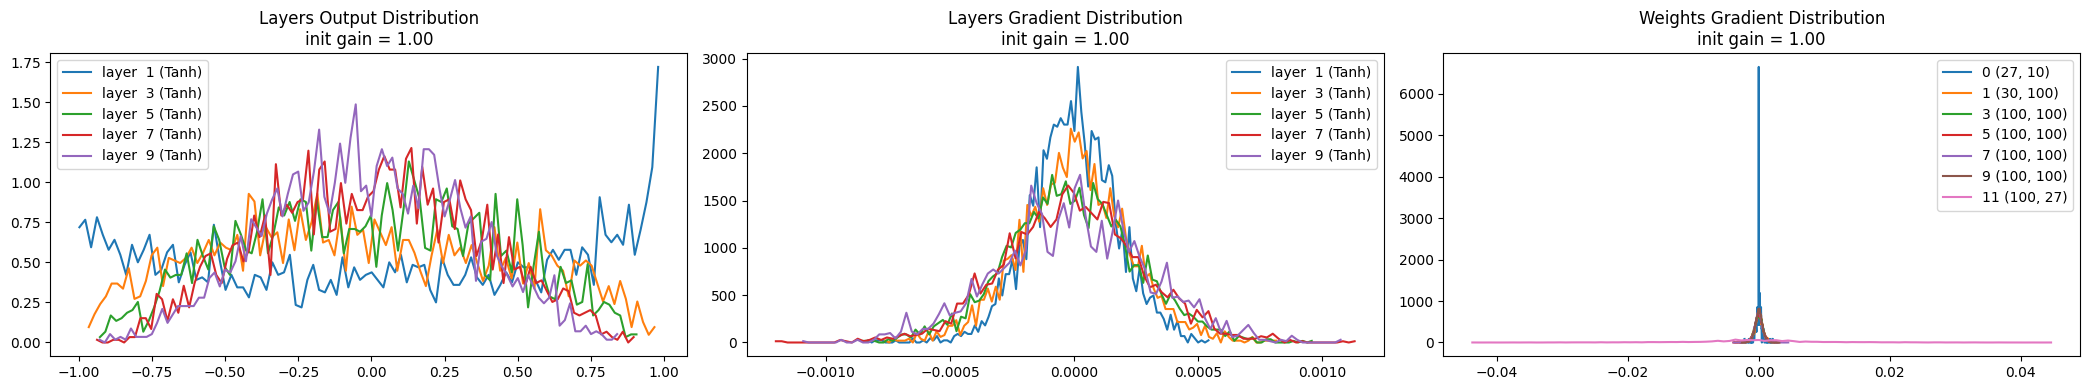

##### Layers Output Distribution (init gain = 1.00)
layer  1 (Tanh): mean = 0.045381 | std = 0.640254 | saturated =   6.94%
layer  3 (Tanh): mean = -0.027767 | std = 0.487841 | saturated =   0.19%
layer  5 (Tanh): mean = -0.002199 | std = 0.417659 | saturated =   0.00%
layer  7 (Tanh): mean = 0.004819 | std = 0.359210 | saturated =   0.00%
layer  9 (Tanh): mean = -0.005270 | std = 0.327599 | saturated =   0.00%
##### Layers Gradient Distribution (init gain = 1.00)
layer  1 (Tanh): mean = 0.000001 | std = 0.000172
layer  3 (Tanh): mean = 0.000009 | std = 0.000218
layer  5 (Tanh): mean = -0.000002 | std = 0.000257
layer  7 (Tanh): mean = 0.000005 | std = 0.000280
layer  9 (Tanh): mean = 0.000007 | std = 0.000299
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = +0.000009 | std = 4.244559e-04 | grad:data ratio = 4.240958e-04
weight 1 (30, 100) | mean = +0.000005 | std = 7.100657e-04 | grad:data ratio = 3.892746e-03
weight 3 (100, 100) | mean = -0.000002 | s

In [ ]:
plot_model_graphs(1, Tanh, init_gain=1)

For this experiment `Tanh layers - no init gain`, after $1$ training step, we can conclude the following:

**Outputs**:
- Tanh saturation degrades to zero across layers.

**Tanh Layer Gradients:**
- Gradients are stable across layers slightly decreasing as they backpropagate.

**Weights Gradients:**
- Weight gradients are stable across layers although a bit small. The output layer's weights are 100x bigger than remaining layers though, and its updates are as big as their data.

**Conclusion:**
- The model will probably be able to learn fine as it can use its weights to compensate for the lack of post activation gain. Its just not starting from the best state.

And now train it longer:

      1/  10000: 3.297624
  10000/  10000: 2.114273


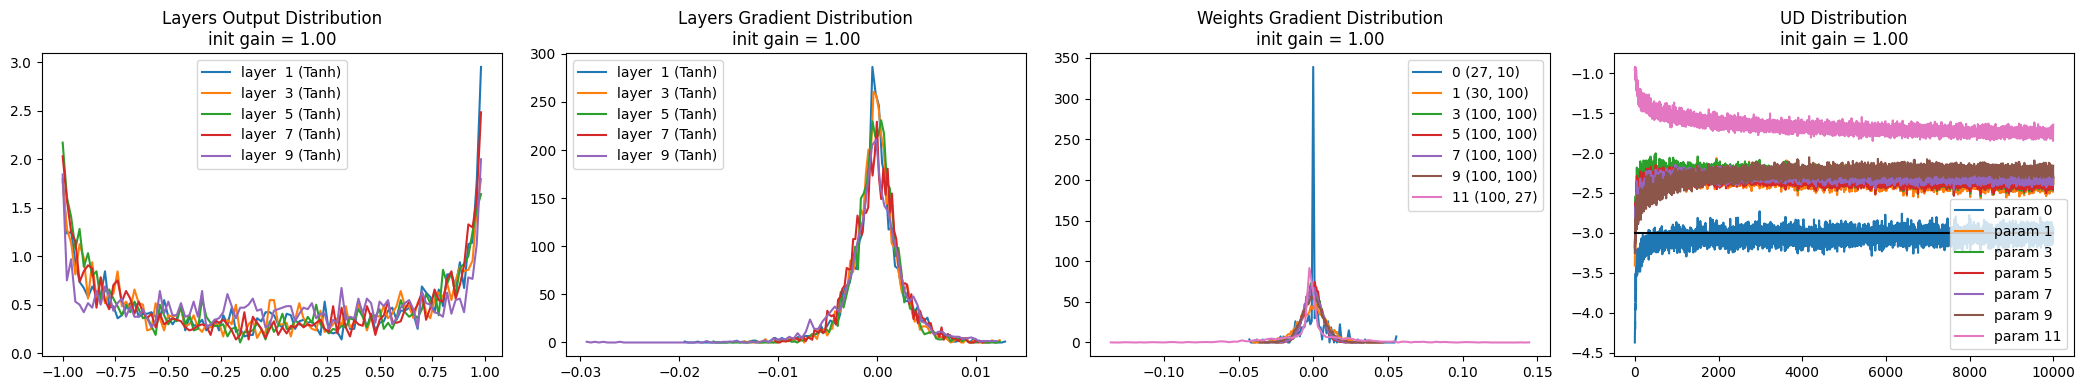

##### Layers Output Distribution (init gain = 1.00)
layer  1 (Tanh): mean = 0.043287 | std = 0.707567 | saturated =  12.47%
layer  3 (Tanh): mean = -0.011193 | std = 0.697006 | saturated =   9.72%
layer  5 (Tanh): mean = -0.033061 | std = 0.716908 | saturated =  11.19%
layer  7 (Tanh): mean = 0.003126 | std = 0.722676 | saturated =  12.25%
layer  9 (Tanh): mean = 0.007479 | std = 0.640551 | saturated =   9.47%
##### Layers Gradient Distribution (init gain = 1.00)
layer  1 (Tanh): mean = 0.000029 | std = 0.002770
layer  3 (Tanh): mean = -0.000032 | std = 0.002421
layer  5 (Tanh): mean = 0.000075 | std = 0.002326
layer  7 (Tanh): mean = 0.000014 | std = 0.002633
layer  9 (Tanh): mean = -0.000066 | std = 0.003284
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = +0.000612 | std = 1.116371e-02 | update:data ratio = 1.054700e-03
weight 1 (30, 100) | mean = +0.000184 | std = 1.045270e-02 | update:data ratio = 4.572019e-03
weight 3 (100, 100) | mean = -0.000089

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=1)

For this experiment `Tanh layers - no init gain`, after $10k$ training steps, we can conclude the following:

**Outputs**:
- Tanh saturation is improving across layers as epxpected.

**Tanh Layer Gradients:**
- Gradients are stable across layers.

**Weights Gradients:**
- Gradients are stable across layers with the last layer still lagging behind.

**Conclusion:**
- The model performed good enough.

Let's log the results:

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| Tanh layers - no init + batch norm + 10x learning rate | 2.21    |
| Tanh layers - optimal init gain | 1.99    |
| **Tanh layers - optimal init gain + batch norm** | **1.96**    |
| Tanh layers - small init gain | 2.14    |
| Tanh layers - small init gain + batch norm | 2.02  |
| Tanh layers - no init gain | 2.11  |

## Tanh layers - no init gain + batch norm

      1/      1: 3.284986


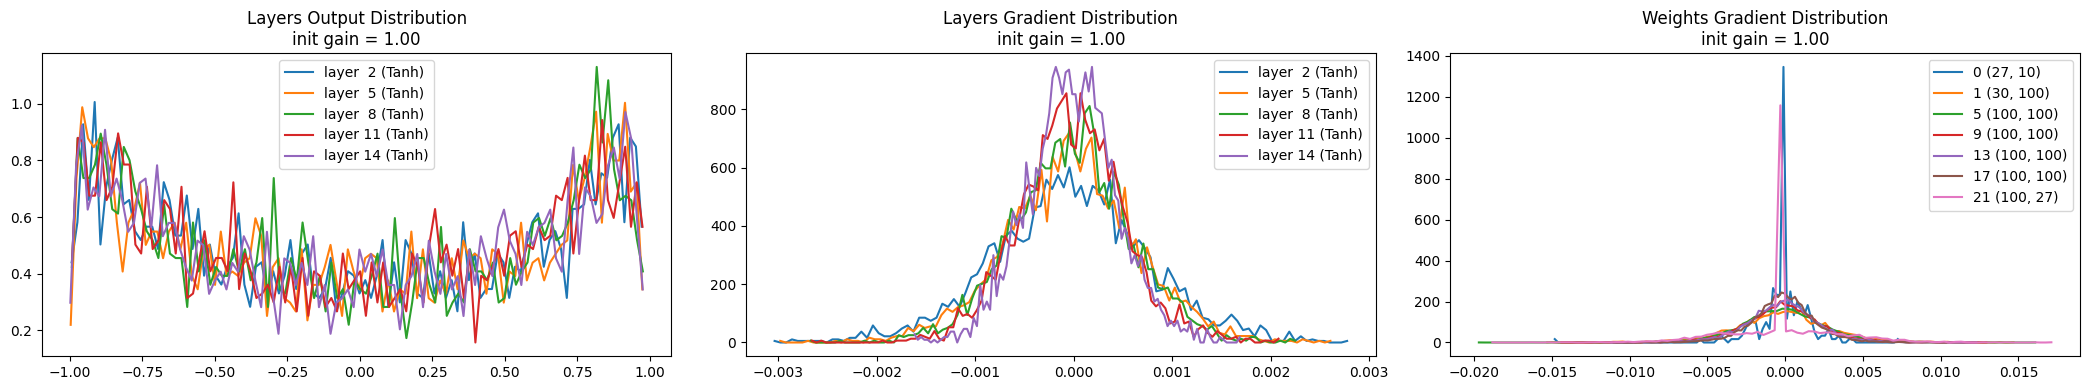

##### Layers Output Distribution (init gain = 1.00)
layer  2 (Tanh): mean = -0.005781 | std = 0.636436 | saturated =   2.25%
layer  5 (Tanh): mean = 0.000413 | std = 0.638778 | saturated =   2.22%
layer  8 (Tanh): mean = 0.000681 | std = 0.640061 | saturated =   2.47%
layer 11 (Tanh): mean = 0.000004 | std = 0.638393 | saturated =   2.69%
layer 14 (Tanh): mean = 0.001923 | std = 0.636566 | saturated =   2.44%
##### Layers Gradient Distribution (init gain = 1.00)
layer  2 (Tanh): mean = -0.000000 | std = 0.000801
layer  5 (Tanh): mean = -0.000000 | std = 0.000677
layer  8 (Tanh): mean = 0.000000 | std = 0.000603
layer 11 (Tanh): mean = -0.000000 | std = 0.000535
layer 14 (Tanh): mean = 0.000000 | std = 0.000457
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = -0.000000 | std = 1.718000e-03 | grad:data ratio = 1.716543e-03
weight 1 (30, 100) | mean = -0.000000 | std = 3.184863e-03 | grad:data ratio = 1.746014e-02
weight 5 (100, 100) | mean = +0.000001 | s

In [ ]:
plot_model_graphs(1, Tanh, init_gain=1, batch_norm=True)

For this experiment `Tanh layers - no init gain + batch norm`, after 1 training step, we can conclude the following:

**Outputs**:
- Tanh saturation is stable across layers.

**Tanh Layer Gradients:**
- Gradients are stable across layers.

**Weights Gradients:**
- Gradients are stable across layers.

**Conclusion:**
- The model is stable and ready to learn.

      1/  10000: 3.284986
  10000/  10000: 2.050674


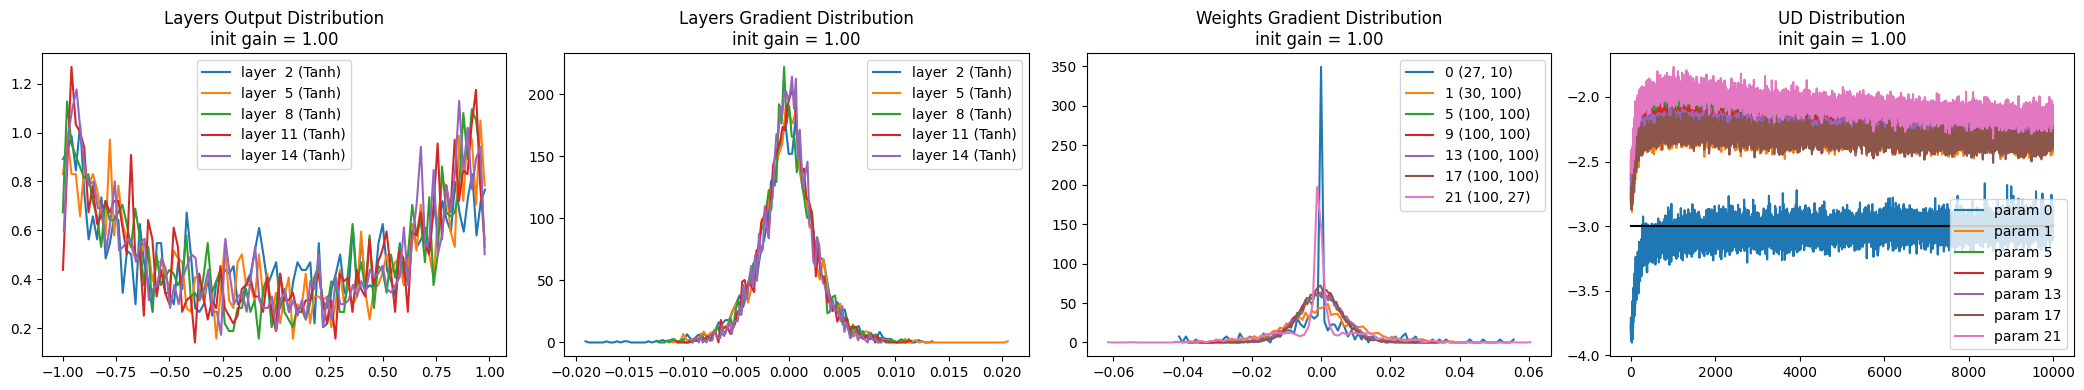

##### Layers Output Distribution (init gain = 1.00)
layer  2 (Tanh): mean = -0.005493 | std = 0.641414 | saturated =   4.59%
layer  5 (Tanh): mean = -0.011774 | std = 0.663161 | saturated =   4.97%
layer  8 (Tanh): mean = -0.000053 | std = 0.668723 | saturated =   3.84%
layer 11 (Tanh): mean = -0.000467 | std = 0.670223 | saturated =   3.44%
layer 14 (Tanh): mean = 0.000436 | std = 0.667699 | saturated =   3.25%
##### Layers Gradient Distribution (init gain = 1.00)
layer  2 (Tanh): mean = -0.000000 | std = 0.003092
layer  5 (Tanh): mean = 0.000000 | std = 0.002868
layer  8 (Tanh): mean = -0.000000 | std = 0.002704
layer 11 (Tanh): mean = 0.000000 | std = 0.002541
layer 14 (Tanh): mean = 0.000000 | std = 0.002387
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = +0.000000 | std = 1.302044e-02 | update:data ratio = 1.295143e-03
weight 1 (30, 100) | mean = +0.000638 | std = 1.180318e-02 | update:data ratio = 5.618519e-03
weight 5 (100, 100) | mean = +0.0000

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=1, batch_norm=True)

Again we may get better loss from lower learning rate:

      1/  10000: 3.284986
  10000/  10000: 2.049059


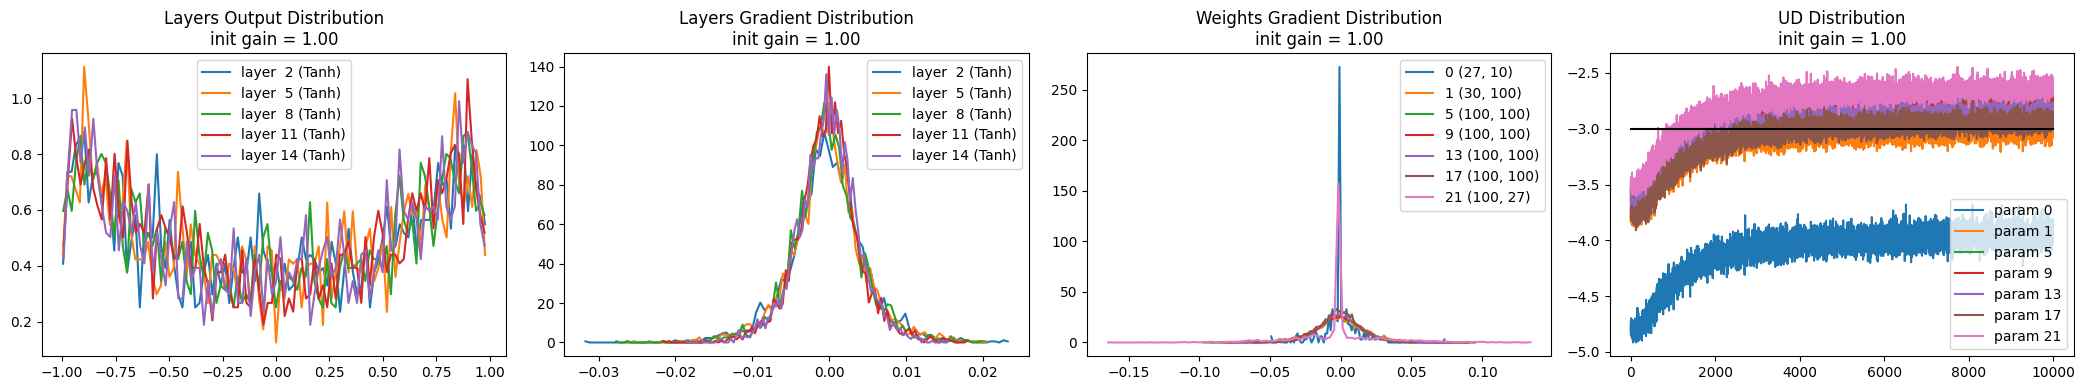

##### Layers Output Distribution (init gain = 1.00)
layer  2 (Tanh): mean = -0.001581 | std = 0.633547 | saturated =   2.72%
layer  5 (Tanh): mean = -0.000645 | std = 0.636132 | saturated =   2.84%
layer  8 (Tanh): mean = -0.001127 | std = 0.640281 | saturated =   2.94%
layer 11 (Tanh): mean = -0.001501 | std = 0.644816 | saturated =   2.22%
layer 14 (Tanh): mean = 0.004726 | std = 0.642318 | saturated =   2.31%
##### Layers Gradient Distribution (init gain = 1.00)
layer  2 (Tanh): mean = -0.000000 | std = 0.005039
layer  5 (Tanh): mean = -0.000000 | std = 0.004875
layer  8 (Tanh): mean = 0.000000 | std = 0.004534
layer 11 (Tanh): mean = -0.000000 | std = 0.004022
layer 14 (Tanh): mean = -0.000000 | std = 0.003888
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = -0.000000 | std = 1.341180e-02 | update:data ratio = 1.339982e-04
weight 1 (30, 100) | mean = +0.000625 | std = 2.071008e-02 | update:data ratio = 1.131202e-03
weight 5 (100, 100) | mean = -0.00

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=1, batch_norm=True, learning_rate=LEARNING_RATE*10**-1)

For this experiment `Tanh layers - no init gain + batch norm`, after $10k$ training steps, we can conclude the following:

**Outputs**:
- Tanh saturation is stable across layers.

**Tanh Layer Gradients:**
- Gradients are stable across layers.

**Weights Gradients:**
- Gradients are stable across layers.

**Update data ratios:**
- Ratios are stable across layers.

**Conclusion:**
- The model is stable and ready to learn.

Let's log the results:

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| Tanh layers - no init + batch norm | 2.11    |
| Tanh layers - no init + batch norm + 10x learning rate | 2.21    |
| Tanh layers - optimal init gain | 1.99    |
| **Tanh layers - optimal init gain + batch norm** | **1.96**    |
| Tanh layers - small init gain | 2.14    |
| Tanh layers - small init gain + batch norm | 2.02  |
| Tanh layers - no init gain | 2.11  |
| Tanh layers - no init gain + batch norm | 2.05 |

## Tanh layers - large init gain

And now when the init gain is large:

      1/      1: 3.285405


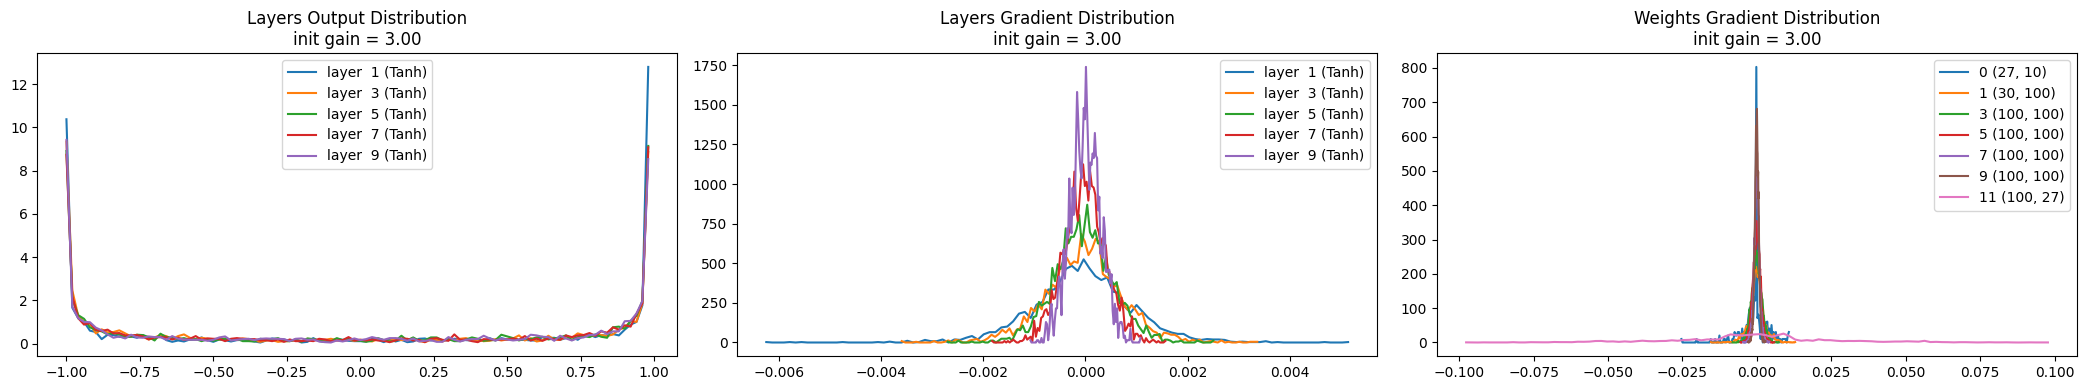

##### Layers Output Distribution (init gain = 3.00)
layer  1 (Tanh): mean = 0.051701 | std = 0.862766 | saturated =  50.44%
layer  3 (Tanh): mean = -0.048838 | std = 0.840364 | saturated =  41.22%
layer  5 (Tanh): mean = 0.002177 | std = 0.838393 | saturated =  41.12%
layer  7 (Tanh): mean = -0.000024 | std = 0.839121 | saturated =  39.78%
layer  9 (Tanh): mean = -0.002860 | std = 0.834833 | saturated =  40.00%
##### Layers Gradient Distribution (init gain = 3.00)
layer  1 (Tanh): mean = -0.000004 | std = 0.000992
layer  3 (Tanh): mean = 0.000000 | std = 0.000767
layer  5 (Tanh): mean = -0.000010 | std = 0.000579
layer  7 (Tanh): mean = -0.000004 | std = 0.000416
layer  9 (Tanh): mean = 0.000007 | std = 0.000299
##### Weights Gradient Distribution (init gain = 3.00)
weight 0 (27, 10) | mean = -0.000429 | std = 4.446980e-03 | grad:data ratio = 4.443217e-03
weight 1 (30, 100) | mean = +0.000024 | std = 2.602522e-03 | grad:data ratio = 4.755876e-03
weight 3 (100, 100) | mean = -0.000002 |

In [ ]:
plot_model_graphs(1, Tanh, init_gain=3)

**Outputs**:
- With a init gain of 3, tanh outputs are mostly -1 and 1. The gain is consistently moving the value to the extremes of the range where tanh starts squeezing values to -1 and 1. After each of these comprissions, the gain pushes the value outwards beyond the range [-2, 2] again, making the next tanh operation compress it back to -1 or 1 once more.

**Tanh Layer Gradients:**
- Most gradients are very close to zero, with the ones in the earlier layers being the biggest, since their values are large enough comparing to other layers as to compensate for the vanishing gradient caused by the chain rule.

**Weights Gradients:**
- Weight gradients are small.

**Conclusion:**
- This network should not learn at all, even if the first layer learns something, the last layers cant adapt any of their parameters so ultimately no classification is learned.

Let's train for longer:

      1/  10000: 3.285405
  10000/  10000: 2.083468


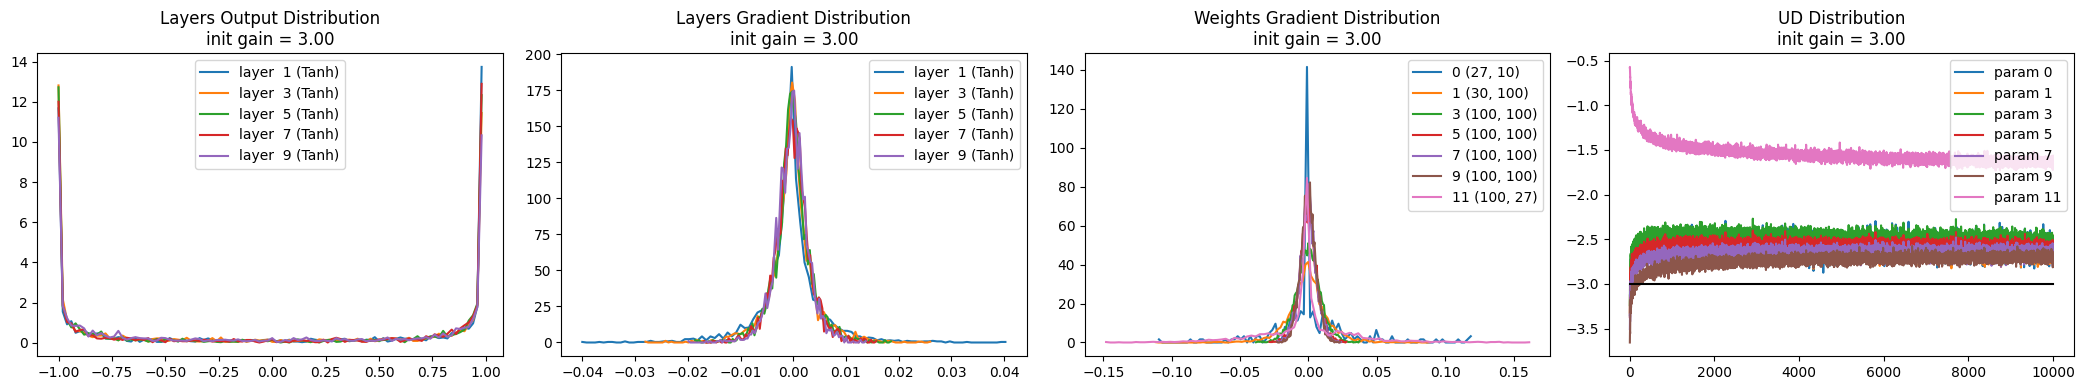

##### Layers Output Distribution (init gain = 3.00)
layer  1 (Tanh): mean = 0.042008 | std = 0.884742 | saturated =  54.72%
layer  3 (Tanh): mean = -0.034598 | std = 0.882868 | saturated =  52.97%
layer  5 (Tanh): mean = 0.000480 | std = 0.896416 | saturated =  54.31%
layer  7 (Tanh): mean = 0.042533 | std = 0.892373 | saturated =  54.06%
layer  9 (Tanh): mean = -0.041944 | std = 0.865822 | saturated =  47.59%
##### Layers Gradient Distribution (init gain = 3.00)
layer  1 (Tanh): mean = -0.000102 | std = 0.006172
layer  3 (Tanh): mean = 0.000084 | std = 0.004396
layer  5 (Tanh): mean = 0.000044 | std = 0.003682
layer  7 (Tanh): mean = 0.000003 | std = 0.003395
layer  9 (Tanh): mean = -0.000068 | std = 0.003143
##### Weights Gradient Distribution (init gain = 3.00)
weight 0 (27, 10) | mean = +0.002848 | std = 2.857365e-02 | grad:data ratio = 2.793477e-02
weight 1 (30, 100) | mean = +0.000399 | std = 1.519658e-02 | grad:data ratio = 2.694052e-02
weight 3 (100, 100) | mean = +0.000116 | s

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=3)

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| **Tanh layers - gain = 5/3** | **2.01**    |
| Tanh layers - gain = 1/2 | 2.24    |
| Tanh layers - gain = 1   | 2.02    |
| Tanh layers - gain = 3   | 1.99    |

**Outputs**:
- Output distribution is consistent with initialization.

**Tanh Layer Gradients:**
- Gradients are small
- Gradients become smaller as they backpropagate from last layer to first (vanishing gradient problem).

**Weights Gradients:**
- Gradients are small
- Gradients become smaller as they backpropagate from last layer to first (vanishing gradient problem).

**Update data ratio:*
- All seem ok, but output layer doesnt seem to be fixing itself.

**Conclusion:**
- Network is learning something.

## Tanh layers - large init gain + batch norm

      1/      1: 3.284986


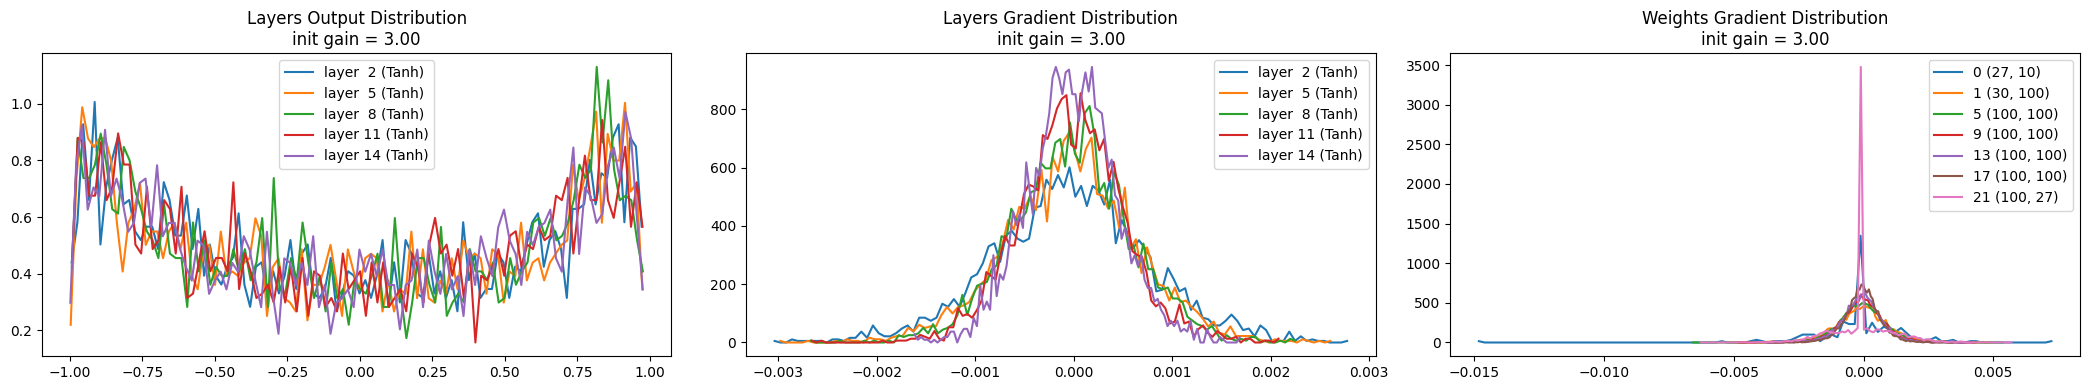

##### Layers Output Distribution (init gain = 3.00)
layer  2 (Tanh): mean = -0.005781 | std = 0.636437 | saturated =   2.25%
layer  5 (Tanh): mean = 0.000413 | std = 0.638783 | saturated =   2.22%
layer  8 (Tanh): mean = 0.000681 | std = 0.640065 | saturated =   2.47%
layer 11 (Tanh): mean = 0.000004 | std = 0.638397 | saturated =   2.69%
layer 14 (Tanh): mean = 0.001923 | std = 0.636570 | saturated =   2.44%
##### Layers Gradient Distribution (init gain = 3.00)
layer  2 (Tanh): mean = 0.000000 | std = 0.000801
layer  5 (Tanh): mean = 0.000000 | std = 0.000677
layer  8 (Tanh): mean = -0.000000 | std = 0.000603
layer 11 (Tanh): mean = -0.000000 | std = 0.000535
layer 14 (Tanh): mean = 0.000000 | std = 0.000457
##### Weights Gradient Distribution (init gain = 3.00)
weight 0 (27, 10) | mean = +0.000000 | std = 1.718041e-03 | grad:data ratio = 1.716583e-03
weight 1 (30, 100) | mean = -0.000000 | std = 1.061648e-03 | grad:data ratio = 1.940068e-03
weight 5 (100, 100) | mean = +0.000000 | st

In [ ]:
plot_model_graphs(1, Tanh, init_gain=3, batch_norm=True)

      1/  10000: 3.284986
  10000/  10000: 1.944877


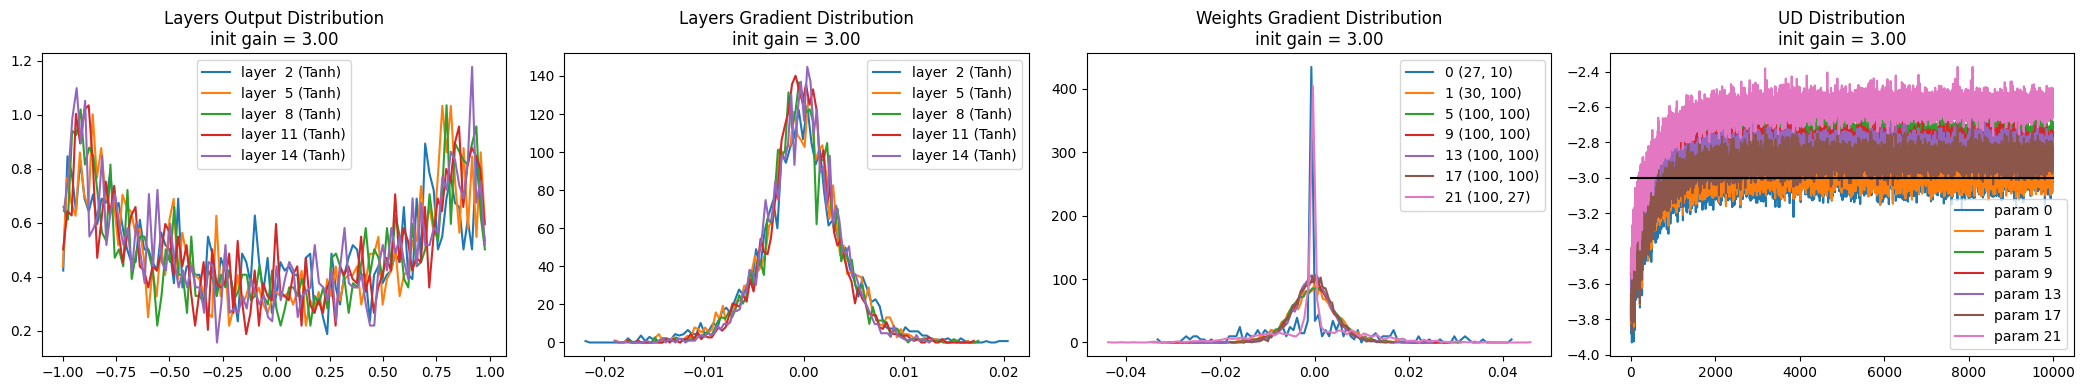

##### Layers Output Distribution (init gain = 3.00)
layer  2 (Tanh): mean = -0.014796 | std = 0.627944 | saturated =   2.97%
layer  5 (Tanh): mean = -0.000351 | std = 0.649624 | saturated =   3.28%
layer  8 (Tanh): mean = 0.006503 | std = 0.651681 | saturated =   3.00%
layer 11 (Tanh): mean = -0.003253 | std = 0.650082 | saturated =   3.03%
layer 14 (Tanh): mean = -0.006147 | std = 0.653634 | saturated =   2.97%
##### Layers Gradient Distribution (init gain = 3.00)
layer  2 (Tanh): mean = -0.000000 | std = 0.004529
layer  5 (Tanh): mean = -0.000000 | std = 0.004080
layer  8 (Tanh): mean = 0.000000 | std = 0.003756
layer 11 (Tanh): mean = 0.000000 | std = 0.003564
layer 14 (Tanh): mean = -0.000000 | std = 0.003572
##### Weights Gradient Distribution (init gain = 3.00)
weight 0 (27, 10) | mean = -0.000000 | std = 1.107047e-02 | grad:data ratio = 1.099992e-02
weight 1 (30, 100) | mean = -0.000023 | std = 5.743935e-03 | grad:data ratio = 1.043880e-02
weight 5 (100, 100) | mean = +0.000067 

In [ ]:
plot_model_graphs(10_000, Tanh, init_gain=3, batch_norm=True)



---

## Linear model - optimal tanh gain

Now, let's examine what happens to the forward and backward pass when we remove the $tanh$ non-linearities:

      1/      1: 4.367826


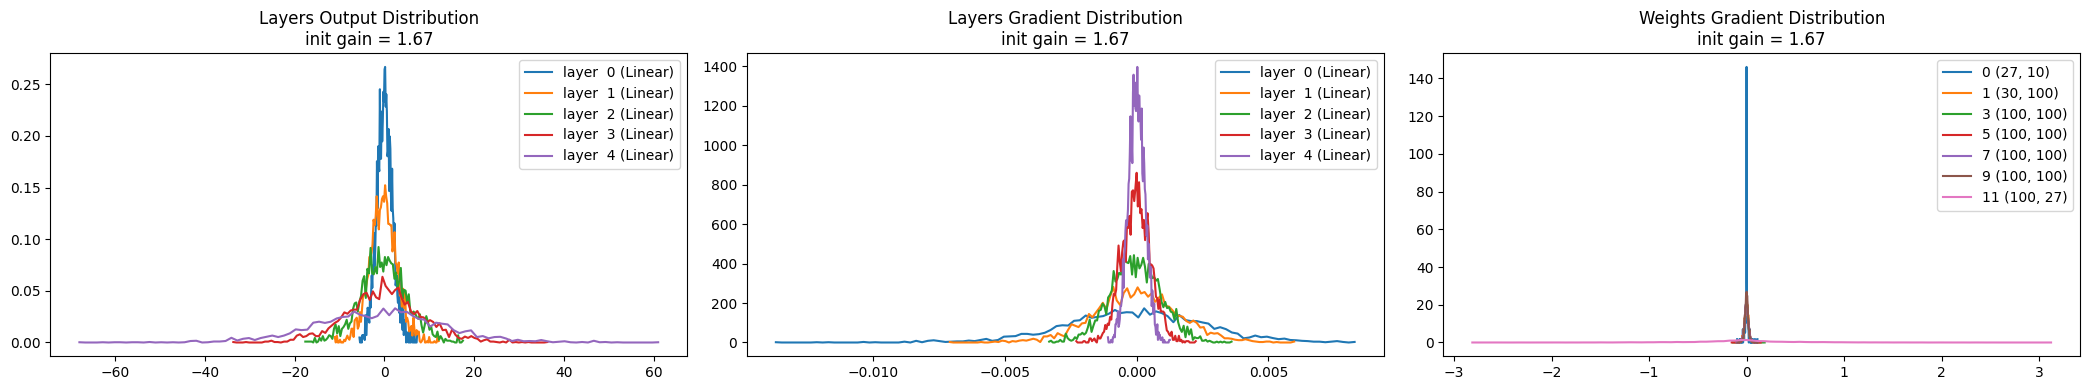

##### Layers Output Distribution (init gain = 1.67)
layer  0 (Linear): mean = 0.177272 | std = 1.848027 | saturated =  57.25%
layer  1 (Linear): mean = -0.161097 | std = 3.084188 | saturated =  73.41%
layer  2 (Linear): mean = 0.019954 | std = 5.273198 | saturated =  85.16%
layer  3 (Linear): mean = 0.271227 | std = 8.545484 | saturated =  89.28%
layer  4 (Linear): mean = -0.667783 | std = 14.591218 | saturated =  93.84%
##### Layers Gradient Distribution (init gain = 1.67)
layer  0 (Linear): mean = 0.000007 | std = 0.002698
layer  1 (Linear): mean = 0.000047 | std = 0.001629
layer  2 (Linear): mean = -0.000011 | std = 0.000972
layer  3 (Linear): mean = 0.000004 | std = 0.000555
layer  4 (Linear): mean = 0.000011 | std = 0.000317
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.000467 | std = 2.021680e-02 | grad:data ratio = 2.021350e-02
weight 1 (30, 100) | mean = -0.000216 | std = 2.128091e-02 | grad:data ratio = 7.004543e-02
weight 3 (100, 100) | 

In [ ]:
plot_model_graphs(1, Linear, non_linearity=None, init_gain=5/3)

**Outputs**:
- Value magnitude increases across layers, starting with a std of 2 and ending with 15.

**Linear Layer Gradients:**
- Gradients are very small.
- Gradients increase as they backpropagate.

**Weights Gradients:**
- Gradients are very small.
- Last layer issue.

**Conclusion:**
- Network will struggle to learn.

Let's train it longer:

      1/      4: 4.367826
      4/      4: 2509.343750


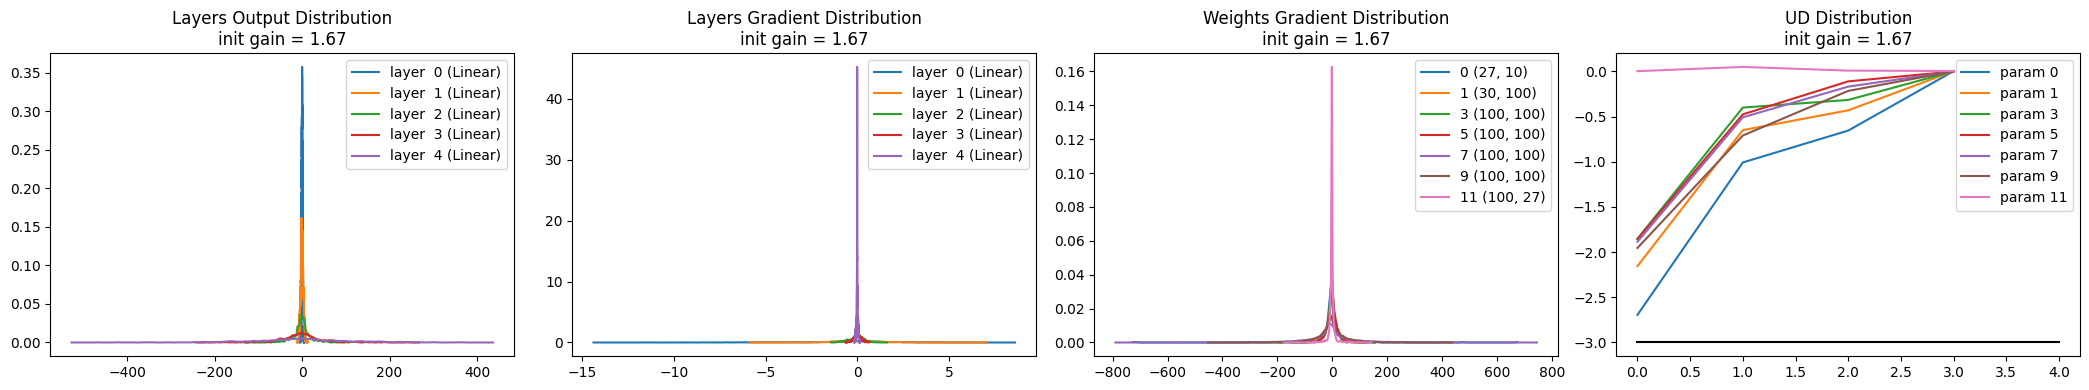

##### Layers Output Distribution (init gain = 1.67)
layer  0 (Linear): mean = -0.006481 | std = 1.330170 | saturated =  45.62%
layer  1 (Linear): mean = -0.103973 | std = 3.099366 | saturated =  75.97%
layer  2 (Linear): mean = -0.233981 | std = 23.886637 | saturated =  93.81%
layer  3 (Linear): mean = -0.293961 | std = 58.302685 | saturated =  97.38%
layer  4 (Linear): mean = 1.578251 | std = 124.244637 | saturated =  99.16%
##### Layers Gradient Distribution (init gain = 1.67)
layer  0 (Linear): mean = -0.492482 | std = 2.872437
layer  1 (Linear): mean = 0.043792 | std = 1.267575
layer  2 (Linear): mean = -0.033118 | std = 0.413914
layer  3 (Linear): mean = 0.006921 | std = 0.173569
layer  4 (Linear): mean = 0.000032 | std = 0.042559
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.067122 | std = 9.399893e+01 | grad:data ratio = 1.005154e+01
weight 1 (30, 100) | mean = -2.161766 | std = 2.101071e+01 | grad:data ratio = 1.007491e+01
weight 3 (100, 1

In [ ]:
plot_model_graphs(4, Linear, non_linearity=None, init_gain=5/3) # TODO: change to log_freq=1

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| **Tanh layers - gain = 5/3** | **2.01**    |
| Tanh layers - gain = 1/2 | 2.24    |
| Tanh layers - gain = 1   | 2.02    |
| Linear model - gain = 5/3   | 572    |

**Outputs**:
- Values start increasing exponentially as they propagate through layers.

**Linear Layer Gradients:**
- Exploding gradients: Gradients start increasing exponentially as they propagate through layers.

**Weights Gradients:**
- Exploding gradients: Gradients start increasing exponentially as they propagate through layers.

**Update ratio:**
- Updates are orders of magnitude higher than the data they are updating.

**Conclusion:**
- Model is fully unable to learn, exploding gradients are leading to huge losses that worsen with training.

## Linear model - optimal tanh gain + batch norm

      1/      1: 3.290421


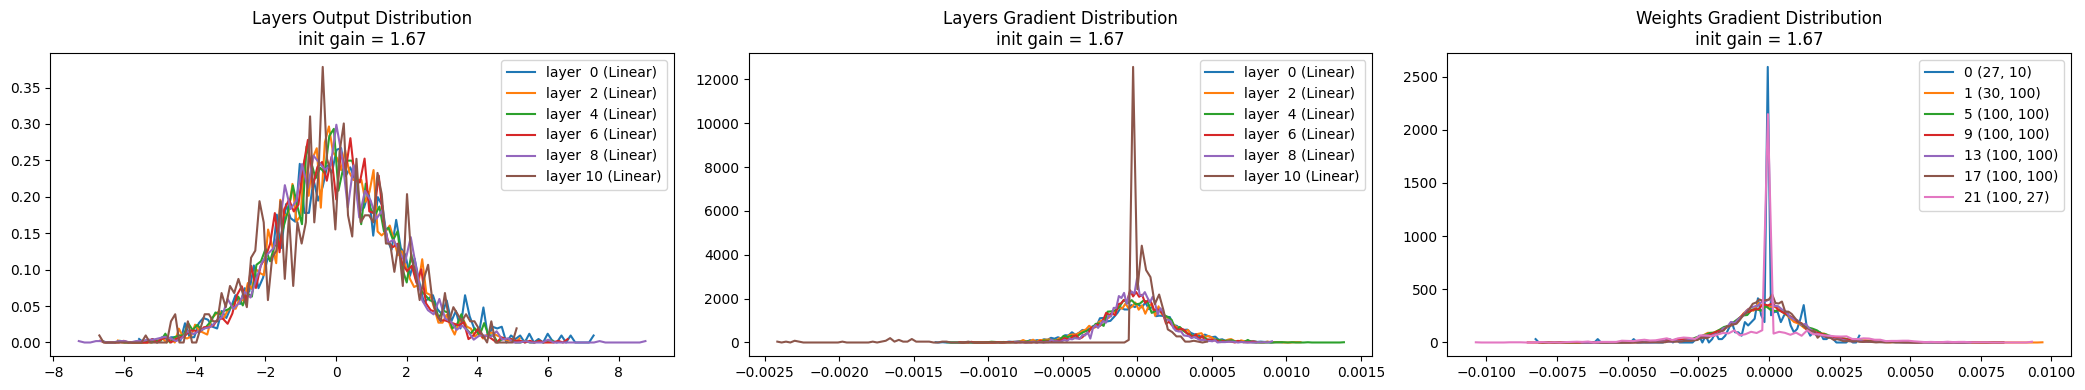

##### Layers Output Distribution (init gain = 1.67)
layer  0 (Linear): mean = 0.177272 | std = 1.848027 | saturated =  57.25%
layer  2 (Linear): mean = -0.000000 | std = 1.623724 | saturated =  54.03%
layer  4 (Linear): mean = 0.000000 | std = 1.680855 | saturated =  54.66%
layer  6 (Linear): mean = 0.000000 | std = 1.622467 | saturated =  53.78%
layer  8 (Linear): mean = 0.000000 | std = 1.667146 | saturated =  54.56%
layer 10 (Linear): mean = -0.000000 | std = 1.795367 | saturated =  57.18%
##### Layers Gradient Distribution (init gain = 1.67)
layer  0 (Linear): mean = 0.000000 | std = 0.000273
layer  2 (Linear): mean = -0.000000 | std = 0.000262
layer  4 (Linear): mean = 0.000000 | std = 0.000242
layer  6 (Linear): mean = -0.000000 | std = 0.000213
layer  8 (Linear): mean = 0.000000 | std = 0.000190
layer 10 (Linear): mean = 0.000000 | std = 0.000342
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.000000 | std = 1.208294e-03 | grad:data ratio = 1

In [ ]:
plot_model_graphs(1, Linear, non_linearity=None, init_gain=5/3, batch_norm=True)

      1/  10000: 3.290421
  10000/  10000: 2.246446


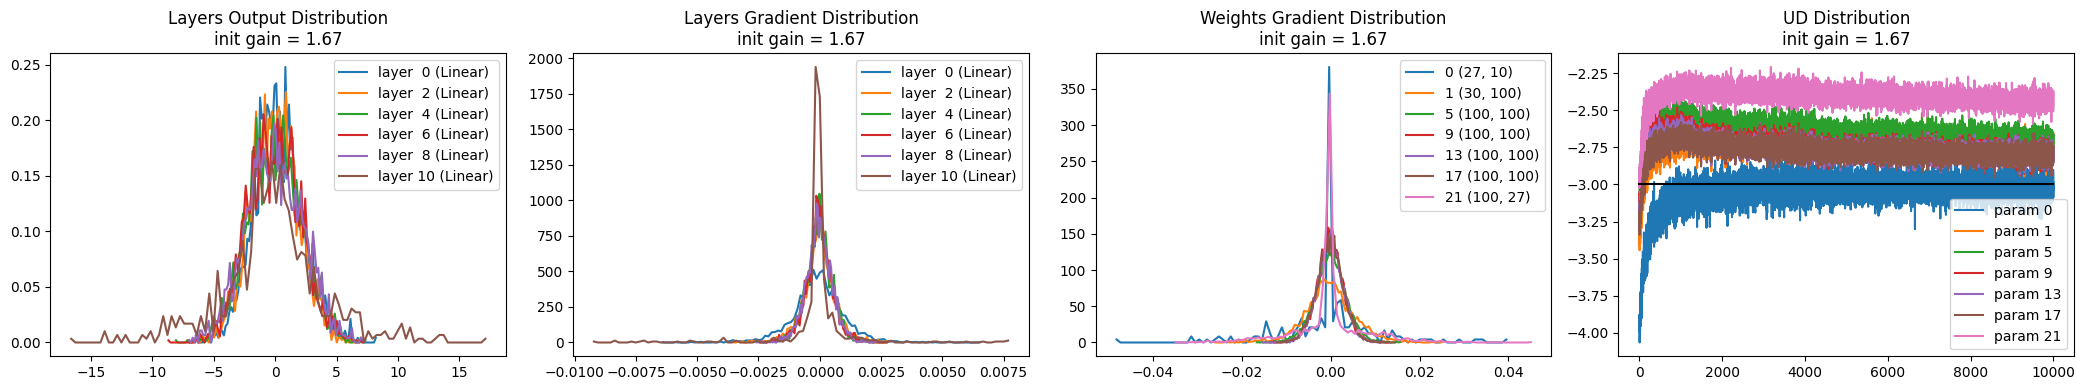

##### Layers Output Distribution (init gain = 1.67)
layer  0 (Linear): mean = 0.287300 | std = 1.958817 | saturated =  61.22%
layer  2 (Linear): mean = -0.000000 | std = 1.935012 | saturated =  62.44%
layer  4 (Linear): mean = -0.000000 | std = 2.140666 | saturated =  66.25%
layer  6 (Linear): mean = 0.000000 | std = 2.119693 | saturated =  66.50%
layer  8 (Linear): mean = -0.000000 | std = 2.293107 | saturated =  68.81%
layer 10 (Linear): mean = 0.000000 | std = 4.137155 | saturated =  72.34%
##### Layers Gradient Distribution (init gain = 1.67)
layer  0 (Linear): mean = -0.000000 | std = 0.001089
layer  2 (Linear): mean = -0.000000 | std = 0.000697
layer  4 (Linear): mean = 0.000000 | std = 0.000560
layer  6 (Linear): mean = -0.000000 | std = 0.000549
layer  8 (Linear): mean = 0.000000 | std = 0.000537
layer 10 (Linear): mean = 0.000000 | std = 0.001306
##### Weights Gradient Distribution (init gain = 1.67)
weight 0 (27, 10) | mean = +0.000000 | std = 1.035881e-02 | grad:data ratio =

In [ ]:
plot_model_graphs(10_000, Linear, non_linearity=None, init_gain=5/3, batch_norm=True)


## Linear model - optimal linear gain

      1/      1: 3.309468


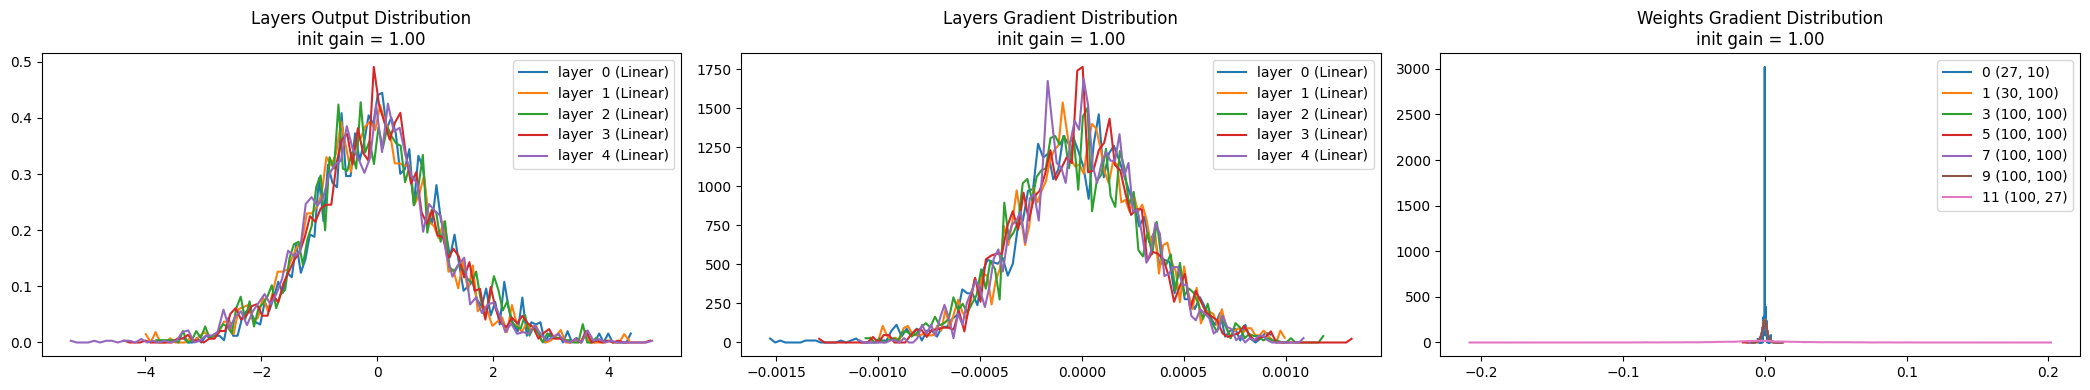

##### Layers Output Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.106363 | std = 1.108816 | saturated =  35.53%
layer  1 (Linear): mean = -0.057995 | std = 1.110308 | saturated =  35.66%
layer  2 (Linear): mean = 0.004310 | std = 1.139011 | saturated =  37.22%
layer  3 (Linear): mean = 0.035151 | std = 1.107495 | saturated =  35.62%
layer  4 (Linear): mean = -0.051927 | std = 1.134613 | saturated =  36.44%
##### Layers Gradient Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.000002 | std = 0.000324
layer  1 (Linear): mean = 0.000013 | std = 0.000327
layer  2 (Linear): mean = -0.000003 | std = 0.000324
layer  3 (Linear): mean = 0.000007 | std = 0.000312
layer  4 (Linear): mean = 0.000007 | std = 0.000300
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = +0.000031 | std = 1.134897e-03 | grad:data ratio = 1.133943e-03
weight 1 (30, 100) | mean = -0.000022 | std = 2.013122e-03 | grad:data ratio = 1.103662e-02
weight 3 (100, 100) | m

In [ ]:
plot_model_graphs(1, Linear, non_linearity=None, init_gain=1)

**Outputs**:
- Values propagation is stable with values assuming same range across all layers.

**Linear Layer Gradients:**
- Gradients are small but stable across layhers.

**Weights Gradients:**
- Gradients are small but stable across layhers. Except last.

**Conclusion:**
- Model should be able to learn, but should have worse loss than one with a non-linear layer.

Let's train longer:

      1/  10000: 3.309468
  10000/  10000: 2.354521


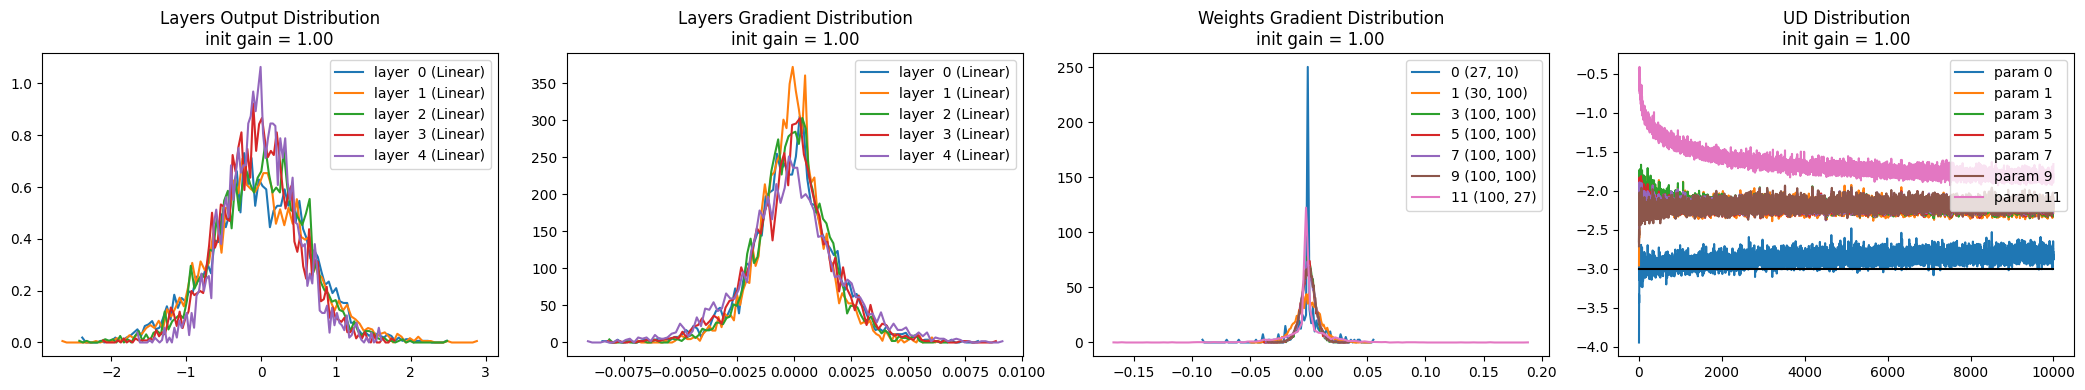

##### Layers Output Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.006531 | std = 0.659369 | saturated =  13.91%
layer  1 (Linear): mean = 0.002299 | std = 0.662752 | saturated =  13.53%
layer  2 (Linear): mean = 0.016486 | std = 0.596957 | saturated =   9.53%
layer  3 (Linear): mean = -0.018646 | std = 0.522730 | saturated =   6.66%
layer  4 (Linear): mean = 0.015094 | std = 0.472046 | saturated =   4.72%
##### Layers Gradient Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.000028 | std = 0.001855
layer  1 (Linear): mean = -0.000000 | std = 0.001499
layer  2 (Linear): mean = 0.000035 | std = 0.001628
layer  3 (Linear): mean = -0.000002 | std = 0.001866
layer  4 (Linear): mean = -0.000020 | std = 0.002201
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = -0.000110 | std = 1.476389e-02 | grad:data ratio = 1.633392e-02
weight 1 (30, 100) | mean = +0.000089 | std = 1.132525e-02 | grad:data ratio = 6.964920e-02
weight 3 (100, 100) | 

In [ ]:
plot_model_graphs(10_000, Linear, non_linearity=None, init_gain=1)

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| **Tanh layers - gain = 5/3** | **2.01**    |
| Tanh layers - gain = 1/2 | 2.24    |
| Tanh layers - gain = 1   | 2.02    |
| Linear model - gain = 5/3   | 572    |
| Linear model - gain = 1   | 2.32    |

**Outputs**:
- Values are smaller but remaing stable across layers. The trend is for values to become smaller as they propagate through layers.

**Linear Layer Gradients:**
- Gradients are small but stable across layers.

**Weights Gradients:**
- Gradients are small but stable across layers. Output layer is improving.

**Update data ratio:**
- Most layers are learning at a healthy rate.
- First layer is struggling to learn comparing to others, but not too bad.
- Output layer update magnitude lowers with each step.

**Conclusion:**
- Model is learning.

## Linear model - optimal linear gain + batch norm

      1/      1: 3.309468


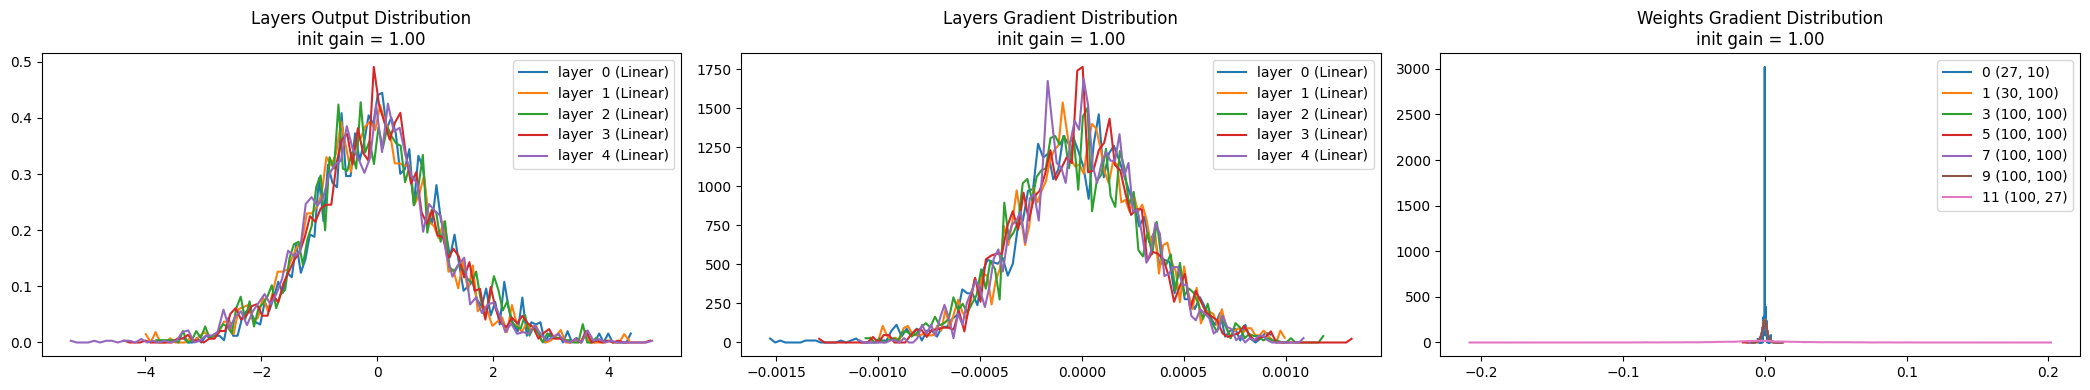

##### Layers Output Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.106363 | std = 1.108816 | saturated =  35.53%
layer  1 (Linear): mean = -0.057995 | std = 1.110308 | saturated =  35.66%
layer  2 (Linear): mean = 0.004310 | std = 1.139011 | saturated =  37.22%
layer  3 (Linear): mean = 0.035151 | std = 1.107495 | saturated =  35.62%
layer  4 (Linear): mean = -0.051927 | std = 1.134613 | saturated =  36.44%
##### Layers Gradient Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.000002 | std = 0.000324
layer  1 (Linear): mean = 0.000013 | std = 0.000327
layer  2 (Linear): mean = -0.000003 | std = 0.000324
layer  3 (Linear): mean = 0.000007 | std = 0.000312
layer  4 (Linear): mean = 0.000007 | std = 0.000300
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = +0.000031 | std = 1.134897e-03 | grad:data ratio = 1.133943e-03
weight 1 (30, 100) | mean = -0.000022 | std = 2.013122e-03 | grad:data ratio = 1.103662e-02
weight 3 (100, 100) | m

In [ ]:
plot_model_graphs(1, Linear, non_linearity=None, init_gain=1)

      1/  10000: 3.290421
  10000/  10000: 2.303761


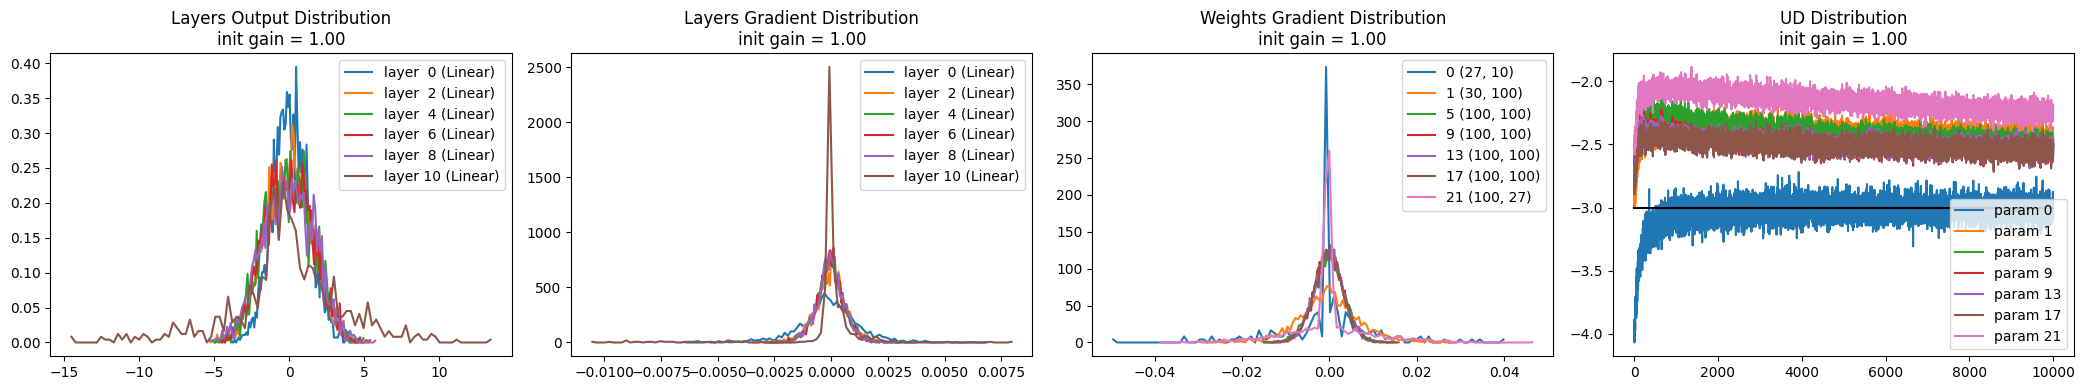

##### Layers Output Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.165360 | std = 1.212548 | saturated =  41.38%
layer  2 (Linear): mean = -0.000000 | std = 1.504961 | saturated =  53.25%
layer  4 (Linear): mean = -0.000000 | std = 1.580747 | saturated =  57.25%
layer  6 (Linear): mean = 0.000000 | std = 1.571379 | saturated =  57.50%
layer  8 (Linear): mean = 0.000000 | std = 1.694119 | saturated =  59.41%
layer 10 (Linear): mean = 0.000000 | std = 3.650648 | saturated =  66.20%
##### Layers Gradient Distribution (init gain = 1.00)
layer  0 (Linear): mean = 0.000000 | std = 0.001340
layer  2 (Linear): mean = 0.000000 | std = 0.000719
layer  4 (Linear): mean = -0.000000 | std = 0.000644
layer  6 (Linear): mean = -0.000000 | std = 0.000633
layer  8 (Linear): mean = 0.000000 | std = 0.000613
layer 10 (Linear): mean = 0.000000 | std = 0.001449
##### Weights Gradient Distribution (init gain = 1.00)
weight 0 (27, 10) | mean = +0.000000 | std = 1.031908e-02 | grad:data ratio = 1

In [ ]:
plot_model_graphs(10_000, Linear, non_linearity=None, init_gain=1, batch_norm=True)


## Linear model - small init gain

      1/      1: 3.296059


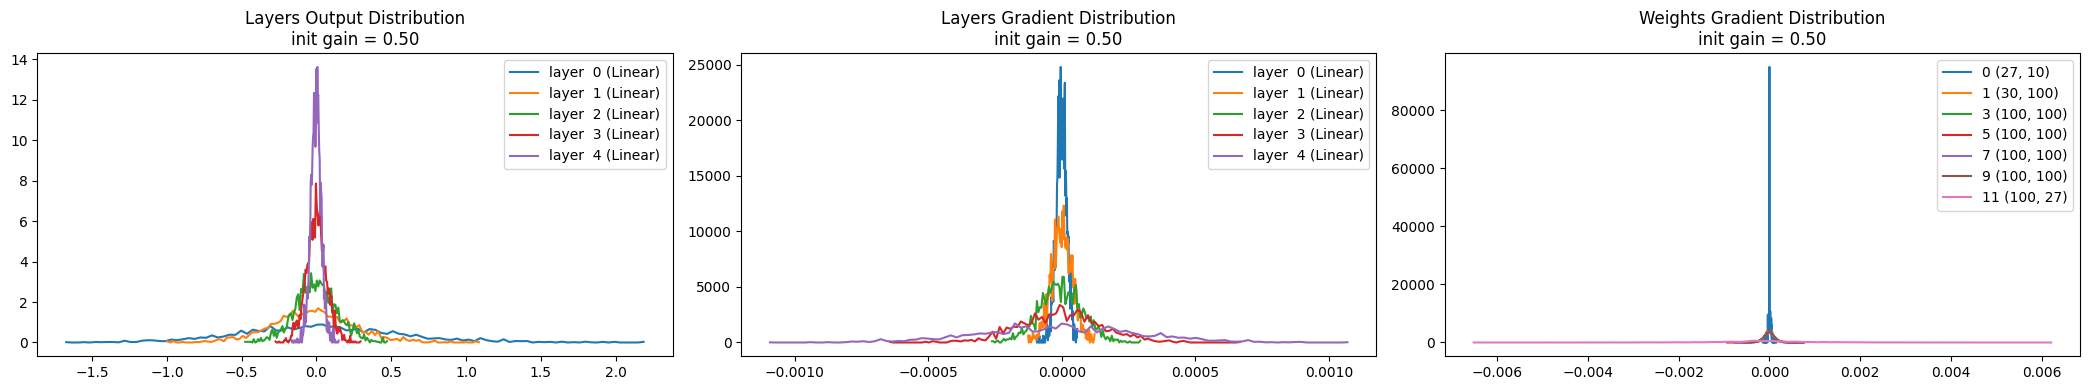

##### Layers Output Distribution (init gain = 0.50)
layer  0 (Linear): mean = 0.053182 | std = 0.554408 | saturated =   8.44%
layer  1 (Linear): mean = -0.014499 | std = 0.277577 | saturated =   0.31%
layer  2 (Linear): mean = 0.000539 | std = 0.142376 | saturated =   0.00%
layer  3 (Linear): mean = 0.002197 | std = 0.069218 | saturated =   0.00%
layer  4 (Linear): mean = -0.001623 | std = 0.035457 | saturated =   0.00%
##### Layers Gradient Distribution (init gain = 0.50)
layer  0 (Linear): mean = 0.000000 | std = 0.000020
layer  1 (Linear): mean = 0.000002 | std = 0.000041
layer  2 (Linear): mean = -0.000001 | std = 0.000081
layer  3 (Linear): mean = 0.000003 | std = 0.000156
layer  4 (Linear): mean = 0.000007 | std = 0.000299
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = +0.000001 | std = 3.539176e-05 | grad:data ratio = 3.536174e-05
weight 1 (30, 100) | mean = -0.000001 | std = 1.244171e-04 | grad:data ratio = 1.364169e-03
weight 3 (100, 100) | m

In [ ]:
plot_model_graphs(1, Linear, non_linearity=None, init_gain=1/2)

**Outputs**:
- Values shrink as they move across layers.

**Linear Layer Gradients:**
- Vanishing gradient problem: Gradients are small and drop to zero as they backpropagate.

**Weights Gradients:**
- Vanishing gradient problem: Gradients are small and drop to zero as they backpropagate.
- Issue with output layer.

**Conclusion:**
- Model will struggle to learn because gradients are failing to backpropagate.

Train for longer:

      1/  10000: 3.296059
  10000/  10000: 2.325411


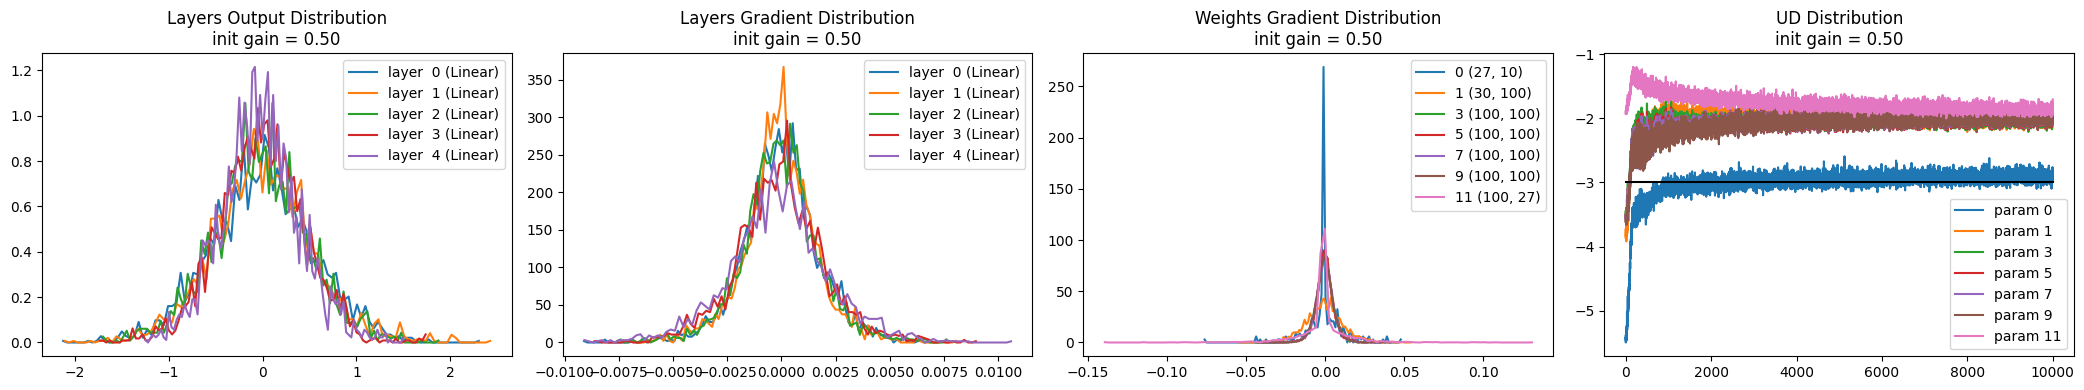

##### Layers Output Distribution (init gain = 0.50)
layer  0 (Linear): mean = 0.013925 | std = 0.554219 | saturated =   8.31%
layer  1 (Linear): mean = 0.029523 | std = 0.544657 | saturated =   7.72%
layer  2 (Linear): mean = -0.009574 | std = 0.500758 | saturated =   5.75%
layer  3 (Linear): mean = 0.001750 | std = 0.450051 | saturated =   3.12%
layer  4 (Linear): mean = -0.006548 | std = 0.413836 | saturated =   2.53%
##### Layers Gradient Distribution (init gain = 0.50)
layer  0 (Linear): mean = 0.000077 | std = 0.001746
layer  1 (Linear): mean = 0.000022 | std = 0.001640
layer  2 (Linear): mean = 0.000029 | std = 0.001784
layer  3 (Linear): mean = 0.000016 | std = 0.002027
layer  4 (Linear): mean = -0.000034 | std = 0.002330
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = -0.000015 | std = 1.248477e-02 | grad:data ratio = 1.285978e-02
weight 1 (30, 100) | mean = -0.000066 | std = 1.208861e-02 | grad:data ratio = 1.068755e-01
weight 3 (100, 100) | m

In [ ]:
plot_model_graphs(10_000, Linear, non_linearity=None, init_gain=1/2)

| Experiment            | Loss |
|---------------------- |---------------|
| Tanh layers - no initialization | 2.72    |
| **Tanh layers - gain = 5/3** | **2.01**    |
| Tanh layers - gain = 1/2 | 2.24    |
| Tanh layers - gain = 1   | 2.02    |
| Linear model - gain = 5/3   | 572    |
| Linear model - gain = 1   | 2.32    |
| Linear model - gain = 1/2   | 2.34    |

**Outputs**:
- Values propagation has improved.

**Linear Layer Gradients:**
- Gradient propagation has improved.

**Weights Gradients:**
- Gradient propagation has improved.

**Data update ratio:**
- Update rates are improving and converging across layers.

**Conclusion:**
- Model has been able to overcome bad initialization and found a way to backpropagate gradients and is now learning.


## Linear model - small init gain + batch norm

      1/      1: 3.290421


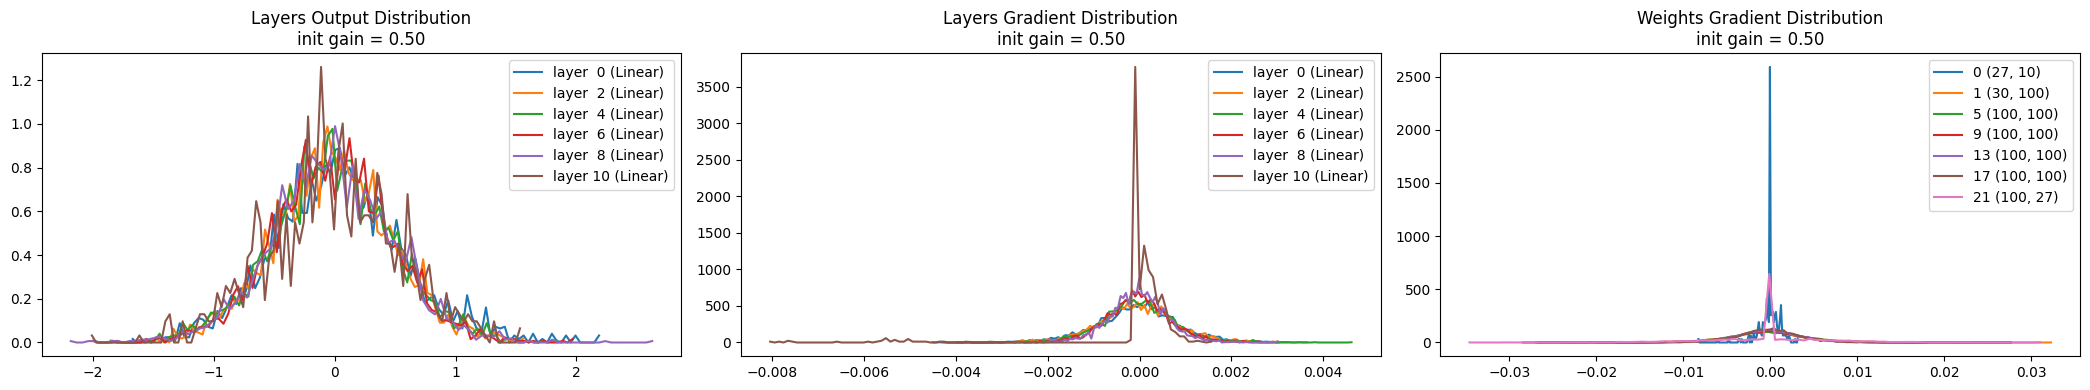

##### Layers Output Distribution (init gain = 0.50)
layer  0 (Linear): mean = 0.053182 | std = 0.554408 | saturated =   8.44%
layer  2 (Linear): mean = 0.000000 | std = 0.487107 | saturated =   4.97%
layer  4 (Linear): mean = 0.000000 | std = 0.504245 | saturated =   6.00%
layer  6 (Linear): mean = 0.000000 | std = 0.486729 | saturated =   4.97%
layer  8 (Linear): mean = 0.000000 | std = 0.500133 | saturated =   5.06%
layer 10 (Linear): mean = 0.000000 | std = 0.538597 | saturated =   6.83%
##### Layers Gradient Distribution (init gain = 0.50)
layer  0 (Linear): mean = -0.000000 | std = 0.000908
layer  2 (Linear): mean = 0.000000 | std = 0.000874
layer  4 (Linear): mean = 0.000000 | std = 0.000807
layer  6 (Linear): mean = -0.000000 | std = 0.000711
layer  8 (Linear): mean = 0.000000 | std = 0.000633
layer 10 (Linear): mean = -0.000000 | std = 0.001139
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = +0.000000 | std = 1.208248e-03 | grad:data ratio = 1.

In [ ]:
plot_model_graphs(1, Linear, non_linearity=None, init_gain=1/2, batch_norm=True)

      1/  10000: 3.290421
  10000/  10000: 2.303239


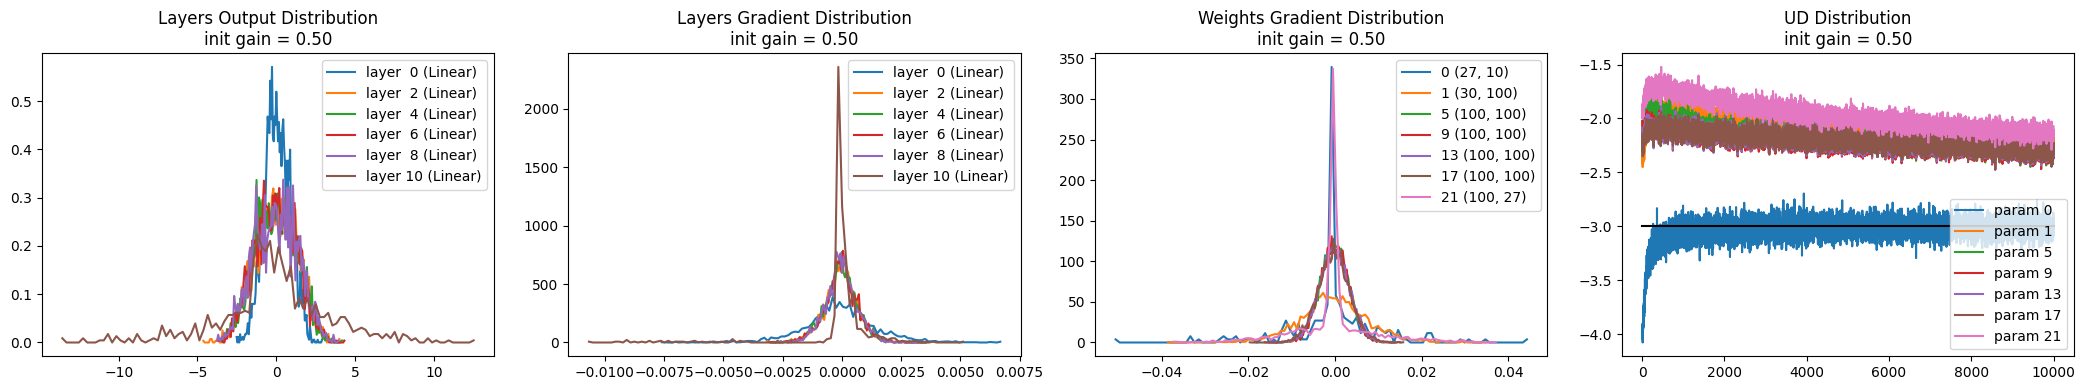

##### Layers Output Distribution (init gain = 0.50)
layer  0 (Linear): mean = 0.087404 | std = 0.810671 | saturated =  23.66%
layer  2 (Linear): mean = 0.000000 | std = 1.317683 | saturated =  49.06%
layer  4 (Linear): mean = -0.000000 | std = 1.284864 | saturated =  49.41%
layer  6 (Linear): mean = 0.000000 | std = 1.291074 | saturated =  48.72%
layer  8 (Linear): mean = 0.000000 | std = 1.362033 | saturated =  52.84%
layer 10 (Linear): mean = -0.000000 | std = 3.474724 | saturated =  65.16%
##### Layers Gradient Distribution (init gain = 0.50)
layer  0 (Linear): mean = -0.000000 | std = 0.001557
layer  2 (Linear): mean = 0.000000 | std = 0.000716
layer  4 (Linear): mean = -0.000000 | std = 0.000721
layer  6 (Linear): mean = 0.000000 | std = 0.000699
layer  8 (Linear): mean = -0.000000 | std = 0.000675
layer 10 (Linear): mean = -0.000000 | std = 0.001486
##### Weights Gradient Distribution (init gain = 0.50)
weight 0 (27, 10) | mean = +0.000000 | std = 1.019056e-02 | grad:data ratio =

In [ ]:
plot_model_graphs(10_000, Linear, non_linearity=None, init_gain=1/2, batch_norm=True)

## Final Run

This is our final benchmark, lets pick up the leading candidate without batch norm and compare it against it with batch norm on a long run.

## Conclusions

Amongst all the previous experiments the following patterns were common when we fiddled with different params:

TODO